# Spark Exact Quantile Analyses

Proposed paper title: "A Quick and Exact Method for Distributed Quantile Computation"

Proposed algorithm name: "GK Select"

Conference Target

* IEEE BigData
  - Deadline Aug 29, 2025
  - mid-tier

* IEEE ICDE International Conference on Data Engineering
  - Deadline June 18, 2025
  - top-tier

In this document we include a time complexity analysis of an exact quantile algorithm designed for
Spark.

```
```


<center> Table @table:defs Notation </center>

| **Symbol**        | **Definition**                                                                               |
|-------------------|----------------------------------------------------------------------------------------------|
| $n$               | Total number of elements across all partitions.                                              |
| $n_i$             | Total elements in the $i$th partition.                                                       |
| $P$               | Number of partitions.                                                                        |
| $q$               | Specific quantile level being queried (e.g., 0.5 for median).                                |
| $\Delta k$        | Rank distance between approximate and exact quantile; satisfies $|\Delta k| \leq \varepsilon n$. |
| $\pi$             | Pivot value.                                                                                  |
| $\varepsilon$     | Desired approximation error; quantile estimates are within $\varepsilon n$ rank positions.   |
| $C_i$             | Number of elements in the $i$th partition that are strictly less than the pivot.             |
| $\tau$            | latency per communication.                                                                   |
| $g$               | time to transmit a communication                                                             |
| $L$               | latency per superstep (or stage in Spark parlance)                                           |

We assume

$$P_{\text{part}} = c\,P_{\text{core}}, \qquad c\ge 1$$

Thus we can use $P$ to denote both $P_{\text{part}}$ and $P_{\text{core}}$ without
affecting the time or space complexity analyses.

## Note on cross-references.

`@ id` marks a definition and `# id` refers to it.  If you install the jupyterlab-mdx jupyterlab
extension <https://github.com/dosirrah/jupyterlab-mdx>, labels and references will be assigned
appropriate numbers every time you run a markdown cell.


## Computation Models

<center>Table @table:models Comparison between Computation Models </center>

|  Feature      |  PRAM          | BSP                                  | CGM                |Spark                                       |
|---------------|----------------|--------------------------------------|--------------------|--------------------------------------------|
| Processors    | up to $O(n)$   | no assumption                        | no assumption      | $P \ll n$                                  |
| Memory        | Shared, global | Local, partitioned                   | Local, partitioned | Local, partitioned                         |
| Access        | Instant        | Local = instant, remote $h + L$      | Local = instant, remote = many-to-many | Local = instant, remote = shuffle, network |
| Communication | $O(1)$ shared memory access | $g h + L$, Expensive    | Expensive          | Expensive                                  |
| Sync          | Lockstep       | Superstep, $L$                       | Round              | Stage (often at shuffle), $L$              |

### Parallel Random-Access Machine (PRAM)

Early work on parallel selection targets the PRAM model.  Notable examples include Cole's
parallel selection ^Cole88 and Han’s deterministic selection ^Han07.  These algorithms assume
shared memory with $O(1)$ time per shared memory access.   Spark, by contrast, is a shared-nothing
platform: data is partitioned, each partition is distributed to an executor (JVM) and memory
accesses within a JVM are assumed to be fast, and communication between executors is orders
of magnitude slower.

Because PRAM abstracts away network communication under the assumption of $O(1)$ shared
memory access, algorithms designed for PRAM would not translate well to the Spark model.

We therefore cite PRAM results for historical context but do not evaluate them further.

### Bulk-Synchronous Parallel (BSP)

A BSP machine has $P$ processors each with local memory. Execution proceeds in *supersteps*.
Each superstep is comprised of

- Local computation
- Point-to-point communication
- Barrier synchronization

The output from one superstep becomes the input to the next.

The time per superstep is modeled as described in ^Valiant90,

$$T = \max(\text{local work}) + g \cdot h + L$$

where $h$ is the maximum communication in words sent by a processor,
$P$ is processors, $g$ is inverse bandwidth, $L$ superstep boundary
latency.

- $h = \max_{1\le i\le P}$
$\bigl(\text{num words processor }i\text{ sends or receives in that superstep}\bigr)$.
    * It is measured in words (or bytes if you multiply by word-size).
	* Only the largest send/receive total among all processors matters, because the superstep cannot finish until that heaviest sender/receiver is done.


The notion of superstep and stage are similar. A superstep comprises the following

1. Local computation on private memory.
2. Arbitrary point-to-point communications.
3. Global barrier: all processes complete a set of operations and synchronize, all messages delivered.

A *stage* is a contiguous set of transformations that can be pipelined without a shuffle
(i.e., only narrow dependencies inside).  A shuffle, broadcast join, or a cached boundary
breaks the pipeline (i.e., a wide dependency) and starts a new stage.

### Coarse-Grained Multiprocessor (CGM)

CGM and BSP are similar.  CGM is a theoretical model that allows worst-case
analysis while abstracting communication cost into a single many-to-many
communication between all processors in each round.  BSP is a more
detailed model that explicitly accounts for computation, latency and bandwidth
in each superstep.

We mention CGM because it is used by Al-Furaih^AlFuraih97 in his description
of Randomized Select.

In this analysis we adapt algorithms for the Spark computational model.


### Spark Model

Spark ^Zahari2010_Spark ^Zaharia2012_RDD ^Zaharia2016_Apache was introduced as a practical system
that unifies multiple paradigms.  It introduces the notion of a Resilient Distributed Dataset^Zaharia2012_RDD.
Each RDD is comprised of a set of partitions distributed across executor nodes.  A partition resides in
a single executor's memory where possible and spills onto disk only if necessary.  The architecture
is a "shared-nothing" architecture in that there is no shared memory between executors.  As with BSP,
computation proceeds locally in each processor (executor) and then when necessary synchronization
between nodes occurs, but the similarities are superficial.   Spark introduces multiple concepts
that do not exist in the BSP model including RDDs, narrow and wide transformations, lazy evaluation,
and actions.

RDDs are themselves immutable and instead Spark applies a transformation to one immutable RDD to
create another immutable RDD.  Transformations that operate on a single partition are known as
narrow transformations.  Transformations that involve moving data between partitions (e.g.,
shuffles) are considered wide transformations.   Narrow transformations affect each
partition in an RDD independently and thus such transformations can proceed asynchronously in
parallel.  Because wide transformations involve communicating between partitions, they necessarily
introduce dependencies.  Only when all dependencies have been satisfied can a computation continue.

Spark introduces the notion of an *action*.  The Spark user specifies transformations on RDDs.
Each transformation is represented as an edge in a Directed Acyclic Graph (DAG).  This DAG
constitutes a lineage: a kind of plan.  The plan is not executed immediately: Spark uses
*lazy evaluation*.   The Spark user builds the DAG by specifying the set of transformations
they wish to perform on their RDDs.  Only when the Spark user requests a result does the plan
execute.  The call to obtain a result is called an *action*.

Spark also introduces the notion of a *stage*.  Spark stages are analogous to BSP supersteps.   Both
represent a barrier before computation can proceed.  However, Spark's notion adds significant
complexity.  Within a stage maximal chains of narrow transformations proceed in parallel
until a wide transformation blocks further progress until that wide transformation completes.

When Spark encounters a wide transformation anywhere in the lineage of the action, it closes out
the entire current stage. No tasks in the subsequent stage—across all branches of the DAG including
those unaffected by the wide transformation—will start until that wide transformation is fully
complete and then the global barrier is crossed.

Spark’s lazy evaluation and DAG scheduler introduce potential optimizations not present in classic BSP.

**Assumption:**

The number of data partitions $P$ is at most a constant factor larger
than the number of executor cores available. Under this assumption, the
number of parallel waves is constant, and thus the wall-clock runtime
complexity remains asymptotically equivalent to the per-wave complexity.
Here wave refers to a set of concurrently processed partitions.

## Performance Evaluation Procedure

Except for historical Sample Sort, which we never implemented
in the Spark context, we will characterize Spark select algorithm
performance along the following dimensions:

1.  Executor time
2.  Driver time
3.	Executor memory
4.  Driver memory
5.  Work
6.  Network latency (barriers + RPC/tree-reduces)
7.	Network volumes (bytes moved cluster-wide)
8.	Number of Shuffles
9.	Number of Actions
10.  Number of Persists

Executor time complexity refers to the cost on the critical path--
the longest dependency chain that dictates wall-clock runtime.

Executor work complexity refers to the total computation performed
by the cluster averaged over the executors. Time complexity
therefore captures the *depth* of the computation, while work
complexity captures the *total effort*.

For the same total work, the job with long dependency chains or
deep trees exhibit longer runtimes than a job that allows all
work to proceed in parallel.

For a driver, there is only one for any given job and thus
the time and work complexity are identical.

Whether one minimizes average per-executor work or time depends on
the situation.  If a cluster is running many jobs, minimizing the
work performed by the cluster will ensure better usage of resources.
If you are only interested in minimizing the time to execute this
one job, time is more important.


## Sequential External-Memory Sample Sort

Frazer and McKellar's Samplesort ^Frazer70 is a sequential
sorting algorithm that is designed for a single processor that sorts
$n$ items where $n$ is much larger than the available memory.  It
selects a value $m$ such that $n/m$ can fit in memory.  The implementor
samples $m$ from the $n$ using an unspecified method.  These $m$ are
assumed to be drawn randomly from the $n$.  The node sorts the $m$ and
then uses each as a bound of $m+1$ buckets.  The system then reads the
data into memory a few at a time (as a stream).  For each element it
finds which bucket it falls in and then writes it into a file for
that bucket.  Once all the data has been written to the $m+1$ files,
they can each be read sequentially into memory, sorted and written back
out.  The concatenation of the $m+1$ buckets is now sorted.

1. Memory‐budgeted sampling:
  Choose $m$ so that $n/m$ (a bucket size) fits in RAM, then draw an
  (unspecified) random sample of $m$ keys from the $n$.

2. Splitter construction:
  Sort the $m$ samples in memory and use them as splitters for $m+1$
  output buckets.

4. Single‐pass bucketing:
  Stream the $n$ items: for each key, determine its bucket by comparing
  against the m splitters, and append it to that bucket’s file (on disk).

5. Recursive in‐memory sorts:
  Each bucket now has at most $\lceil n/(m+1)\rceil$ items; load each into
  RAM, sort it (e.g. Quicksort), and write it out.

6.	Concatenation:
  Finally, concatenate the sorted bucket outputs to produce the globally
  sorted sequence.

## Parallel Sorting by Regular Sampling (PSRS)

Shi, H. & Schaeffer, J. (1992). Parallel Sorting by Regular
Sampling. Journal of Parallel and Distributed Computing, 14(4), 361–372.

Shi et al ^Shi92_PSRS extends Frazer et al's Sample Sort, such
that it is parallel and defines a method for
sampling.  Shi et al's extension is often called "Parallel Sample Sort"
or simply "Sample Sort"; the distinction between Shi et al. and
Frazer et al. is usually clear from context.

Shi et al's Sample Sort assumes a MIMD processor.  However,
it will work with $P$ separate processors that each have only local memory.

precondition: data $X$ is distributed among $P$ processors such
that each processor processes $w=n/P$ elements.

Phase 1: each of $P$ processors sorts its local block of $w$ data using sequential
Quicksort.  When all $P$ processors are done, $X$ is said to be
locally ordered.

Phase 2: each processor generates a *regular sample* $Y$.

A *regular sample* is defined as

$$X_{\tfrac{w}{P} + jw}, X_{\tfrac{2w}{P} + jw}, \dots, X_{\tfrac{(P-1)w}{P} + jw}$$

where $0 \leq j \leq P-1$.  $j$ is a particular processor.  These are the
$\frac{w}{P}$-th, $\frac{2w}{P}$-th, … elements of processor $j$’s local sorted block

Each processor creates a sample of size $P-1$ and communicates these
$P-1$ samples to a single node which sorts the regular sample $Y$
using a sequential Quicksort.  Pick $P-1$ samples from the $Y$ as the
pivots (a.k.a., splitters) for partitioning $X$.  The samples are
picked evenly from $Y$, i.e.,

$$Y_{\tfrac{P}{2}}, Y_{\tfrac{P}{2} + P}, \dots, Y_{\tfrac{P}{2} + P(P-2)}$$

The central node broadcasts the splitters $$Y$$ to the processors.
Each processor uses binary search to find smallest element $\geq$ to each
pivot (splitter).  This breaks up each processor's data into $P$
sorted sublists.

Phase 3:  Each processor $i$ keeps its $i$th sublist and passes the
others to the appropriate processor.  Each processor $i$ performs a
$P$-way merge on the $i$th sublists of $P$ lists.

After sorting the processors synchronize, the sort is done.


### PSRS BSP-style Time complexity

This is a BSP-style time complexity analysis.  While looking at papers related to Spark, I found
that people typically do not do a BSP-style time complexity analysis, but rather break out the
various costs into separate metrics as described in Section #pe.

- Phase 1:

  $$O(w \log w) = O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)$$

- Phase 2: the central processor sorts the regular sample using Quicksort.
  Picks the $P-1$ samples.  Then each processor performs $P-1$ binary searches
  to find the splitters.

  $$O \left(P^2 \log P^2 + (P-1) + (P-1) \log \tfrac{n}{P}\right)$$

  which simplifies to

  $$O \left(P^2 \log P^2 + (P-1) \log \tfrac{n}{P}\right)$$


- Phase 3: each node passes $P-1$ sublists to the other processors.  The original
  paper does not discuss the overhead of communicating the sublists.  In BSP
  terminology this would add a cost:

  $$O(g\tfrac{n}{P})$$

  In distributed dataflow systems like Spark, this maps to shuffle read/write bytes
  and spill cost, which can dominate for large $P$.

  Once the sublists have been distributed, each processor performs a merge of
  $P$ sublists, each of length $\tfrac{w}{P}$.  The merge is accomplished
  recursively as in mergesort resulting in $\log P$ merges.

  $$O \left(\tfrac{n}{P^2} P \log P \right) = O \left(\tfrac{n}{P} \log P \right)$$

The expected total cost thus becomes

$$O\left(\tfrac{n}{P} \log \tfrac{n}{P} + P^2 \log P^2 + (P-1) \log \tfrac{n}{P} + g\tfrac{n}{P} + \tfrac{n}{P} \log P  \right) \tag{@eq:ss}$$

If $n > P^3$ then Equation #eq:ss becomes

$$T_{SS} = O \left(\tfrac{n}{P} \log \tfrac{n}{P} + g\tfrac{n}{P} \right) \tag{@eq:Tss}$$

If we drop the BSP notation and separate the performance characterization into categories of cost.
The time complexity for the processors (executors) becomes

$$T_{exec} = O \left(\tfrac{n}{P} \log \tfrac{n}{P} \right)$$

## Spark Sort

The Spark sort is sometimes called "range-partition-then-sort."  It is similar to
PSRS, but it doesn't sort each partition up front.

1. Sampling (without full local sort)

Each executor samples a constant $m$ records per partition.

2. Collect

The samples are sent to the driver via a `collect()`. The driver collects
from each executor the $m$ records per partition.

3. Driver sorts and picks splitters.

The driver picks $P-1$ split points at the associated quantiles of the sample.

4. Driver broadcasts splitters.

The driver broadcasts the split points via a `TorrentBroadcast`.

5. Range-partitioning shuffle

For each partition, every record is assigned a partition ID by performing
a binary search on the splitters.  The result is $P$ unordered sublists
where all values in sublist $i$ are smaller than all in sublist $i+1$.
For each partition, the executor sends the $i$th sublist to the $i$th
new partition.

6. Local sort within each partition.

Each executor runs Spark's `UnsafeExternalSorter` on its partition resulting from
the range-partitioning shuffle.  As records arrive, they are placed in
a buffer.  If the partition fits in a single buffer then it is sorted
entirely in-memory using a dual-pivot Quicksort.   If a partition reaches the
spill threshold then it is broken into buffers and each buffer as it arrives is
sorted using a dual-pivot Quicksort on primitive arrays and written to disk.
Once all buffers created from a partition are written, the executor performs a
$k$-way merge where $k$ here is the number of buffers comprising the partition.

### Detail

Spark provides several ways to trigger the underlying sort.  If the
programmer directly calls Resilient Distributed Dataset (RDD) operations then

 - `rdd.sortBy(func, ascending=True, numPartitions=None)`
 - `pairRdd.sortByKey(ascending=True, numPartitions=None)`

On the Dataset/DataFrame API:
 - `df.orderBy(col1, col2, …)`
 - `df.sort(col1, col2, …)`

When operating directly on RDDs, the Catalyst Optimizer is bypassed.
If the number of partitions is not small and the user has not
switched on the hash shuffle manager then the default execution
for `RDD.sortByKey` and `RDD.sortBy` looks like:

  - `ShuffledRDD` ⇒ `SortShuffleWriter` ⇒ `UnsafeExternalSorter`

When using the DataFrame API `orderBy` or `sort`, the execution
path follows

  - `DataFrame.orderBy` / `sort` ⇒ Catalyst plan ⇒ `ShuffleExchangeExec` + `SortExec` ⇒ `UnsafeExternalSorter`

Steps 1-5 in the high-level description of Spark's sorting take place in
`SortShuffleWriter` or `ShuffleExchangeExec` + `SortExec`.
`UnsafeExternalSorter` handles step 6 "Local sort within each partition."

`UnsafeExternalSorter` executes as follows:

  buffer → primitive‐array sort → spill → multi‐way merge

It reads records into a buffer of raw bytes.  When the buffer reaches
a threshold or exhausts the input, `UnsafeExternalSorter` performs a
dual-pivot Quicksort ^Nebel16_dual on the buffer generating a run.
If the buffer threshold was reached then it "spills" meaning it writes
the run to the disk to free up space to create a new buffer.  After all
input has been read, any leftover in‐memory buffer is also sorted and
then included as a run.

Once all of the buffers have been sorted, the executor performs a
multi-way merge using min-heap that contains the current minimum from each
run thus bounding the size of the min heap to the number of runs.
Once all the runs have been merged, the entire dataset has been sorted.

Aside: `UnsafeExternalSorter` is called "Unsafe" because it avoids
instantiating JVM objects and instead operates on raw bytes, does
direct pointer arithmetic, direct memory reads and writes, and avoids
JVM's safety nets, e.g., it performs no garbage collection of individual
records, no array bound checks on every access, and no Java type checks.
These are just tradeoffs for performance, but they do not affect the
time complexity of the operations.

### Spark Sort BSP-Style Time Complexity

We do a BSP-like analysis for Spark Sort Time Complexity.   I am not sure whether we want
to use a BSP-like model.  I present a more standard version afterward.

In this analysis $O$ refers to a bound on expected performance.

1. Sampling (without full local sort)

Assuming each partition starts with $\tfrac{n}{P}$ records and we sample $k$ records
from each partition,

$$T_{sample} = \max_i O(n_i)$$

With the expectation of $\tfrac{n}{P}$ records per partition, this becomes

$$T_{sample} = O\left(\tfrac{n}{P}\right).   \tag{@eq:spsort_sample}$$

2. Collect

In BSP terms, each executor sends $h=k$ samples, so the communication cost per executor per
partition is

$$T(k) = g k$$

And the driver performs

$$T(P) = P \cdot (g k) \tag{@eq:spsort_collect1}$$

to aggregate the results.

In #eq:spsort_collect1, the $h$ refers to the maximum number of bytes to communicate a single
sample.

Because these P sends happen in parallel, and adding in the stage cost, $T_{collect}$ becomes

$$T_{\text{collect}}
= \underbrace{g k}_{\text{per‐executor latency \& bandwidth}}
	+ \underbrace{O(P k)}_{\substack{\text{driver CPU to} \\ \text{aggregate all samples}}}
	+ L \tag{@eq:spsort_collect}
$$

3. Driver sorts and picks splitters.

Since the executor for each partition generated $k$ samples,the driver
receives $P k$ sample records resulting in an expected $P k$ sample records
at the driver that must be sorted.  After sorting $P k$. the driver picks
$P-1$ splitters resulting in time complexity for step 3 as

$$T_{splitters} = O\left(P k \log P k) + O(P) \right)$$

Given $k \geq 1$ we can simplify this to

$$T_{splitters} = O\left(P k \log P k\right)   \tag{@eq:spsort_splitters}$$

4. Driver broadcasts splitters.

With high probability the splits are of near equal size.

The driver broadcasts $P-1$ splitters to the executors of $P$ partitions resulting in

$$T_{broadcast} = (g (P-1))\log P + L$$

which simplifies to

$$T_{broadcast} = O\left( g P \log P + L \right)     \tag{@eq:spsort_broadcast}$$

5. Range-partitioning shuffle

The executor takes the $P-1$ splitters using them as the bounds for $P$ buckets.
The executor passes over all records in the partition determining their associated
bucket which takes

$$O(n_i \log P)$$

Under the assumption of evenly sized partitions, this becomes

$$O(\tfrac{n}{P} \log P)$$

The buckets have expected size $\tfrac{n}{P^2}$, i.e., \tfrac{1}{P} of a partition
of expected size $\tfrac{n}{P}$.  The executor then sends every bucket to the
executors for all other partitions reserving one bucket for itself.

$$h = (P-1) \frac{n}{P^2} .$$

$$T_{shuffle} = O(\tfrac{n}{P} \log P) + g h + L$$

Assuming the splits are equally-sized

$$T_{shuffle} = O(\tfrac{n}{P} \log P) + g \tfrac{n}{P^2}(P-1) + L$$

which when expressed in big-$O$ notation for the worst-case bound on the expected time simplifies to

$$T_{shuffle} = O(\tfrac{n}{P} \log P + g \tfrac{n}{P} + L)   \tag{@eq:spsort_shuffle}$$


6. Local sort within each partition.

As buckets arrive, they are buffered.  If a partition fits in a single buffer without
reaching a "spill threshold" then the executor for that partition performs a dual-pivot Quicksort
on the entire partition in memory.

$$T_{localsort} = O(n_i \log n_i) = O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)$$

If a partition fills past a threshold, Spark uses an external sort.  Let $m$ denote the number
records that fit in a buffer before the threshold is reached.  When the threshold is reached,
after sorting, the buffer is "spilled" to disk.  This results in
$b_i = \lceil \tfrac{n_i}{m}\rceil$ buffers.

$$T_{localsort} = b \cdot O( m \log m) = O( n_i \log m)$$

Once all $b_i$ buffers have been sorted, Spark Sort performs a sequential $b_i$-way merge.  This is
accomplished by constructing a min-heap bounded to size $b_i$ containing the smallest element
of each buffer.  The smallest item starts at the top of the first min-heap.  After popping
the minimum, it is streamed to disk, and the next smallest from that buffer is pushed to
the min-heap.   This continues until all items have been written to disk.

$$T_{localmerge} = O(n_i \log b_i)$$

$$T_{local} = T_{localsort} + T_{localmerge}$$

$$T_{local} = O( n_i \log m + n_i \log b_i) = O( n_i \log m + n_i \log \tfrac{n_i}{m}) = O(n_i \log n_i)$$

$$T_{local} = O\left(\tfrac{n}{P} \log \tfrac{n}{P} \right)   \tag{@eq:spsort_local}$$

Combining #eq:spsort_sample and #eq:spsort_collect - #eq:spsort_local yields the expected time of

$$T = T_{sample} + T_{collect} + T_{splitters} + T_{broadcast} + T_{shuffle} + T_{local}$$

$$T =
O(\tfrac{n}{P}) +
(g k + O(P k) + L) +
(O\left(P k \log P k\right)) +
(O\left( g P \log P + L \right)) +
(O(\tfrac{n}{P} \log P + g \tfrac{n}{P} + L)) +
(O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)) \tag{@eq:spsort_total1}$$

Assuming $n > P^2 k$, #eq:spsort_total1 and expressing in big-$O$ notation yields
a worst-case bound on expected time of

$$T =
O\left(\tfrac{n}{P} \log \tfrac{n}{P} + (g k + P k) + g P \log P + g \tfrac{n}{P} + L\right)$$

which simplifies to a BSP-style time complexity of

$$T = O\left(\tfrac{n}{P} \log \tfrac{n}{P} + g P \log P + g \tfrac{n}{P} + L\right)\tag{@eq:spsort_total2}$$


### Spark Sort Executor Time Complexity

Now we drop the BSP-style analysis and break down time complexity into separate metrics
for executor and driver.

The executor time complexity is

$$T_{exec} = T_{sample} + T_{shuffle} + T_{localsort} + T_{localmerge} \tag{@eq:spsort_timeexec}$$

Assuming each partition starts with $\tfrac{n}{P}$ records and we sample $k$ records
from each partition,

$$T_{sample} = \max_i O(n_i)$$

With the expectation of $\tfrac{n}{P}$ records per partition, this becomes

$$T_{sample} = O\left(\tfrac{n}{P}\right).   \tag{@eq:spsort_sample2}$$

The shuffle requires first range partitioning records into $P$ buckets:

$$O(n_i \log P)$$

Under the assumption of evenly sized partitions, this becomes

$$O(\tfrac{n}{P})$$

The executor then serializes and transmits all records outside
the range each executor reserves for its own partition:

$$O(\tfrac{P-1}{P} n_i) = O(n_i) = O(\tfrac{n}{P})$$

The work to transmit is asymptotically less than the work
to sort into buckets so

$$T_{shuffle} = O(\tfrac{n}{P} \log P)$$

From the last two terms of Eq #eq:spsort_timeexec,

$$T_{localsort} + T_{localmerge} = O( n_i \log m + n_i \log b_i) = O( n_i \log m + n_i \log \tfrac{n_i}{m}) = O(n_i \log n_i)$$

Using the same expectation of $\tfrac{n}{P}$ records per partition,

$$T_{exec} = O(\tfrac{n}{P}) + O(\tfrac{n}{P} \log P) + O\left(\tfrac{n}{P} \log \tfrac{n}{P} \right)$$

Under the assumption that $n > P^2$, this becomes

$$T_{exec} = O\left(\tfrac{n}{P} \log \tfrac{n}{P} \right)$$


### Spark Sort Driver Time Complexity

Since the executor for each partition generated $k$ samples,the driver
receives $P k$ sample records resulting in an expected $P k$ sample records
at the driver that must be sorted.  After sorting $P k$. the driver picks
$P-1$ splitters resulting in time complexity for step 3 as

$$T_{splitters} = O\left(P k \log P k) + O(P) \right)$$

Given $k \geq 1$ we can simplify this to

$$T_{splitters} = O\left(P k \log P k\right)   \tag{@eq:spsort_splitters2}$$


### Spark Sort Driver Space Complexity

The driver consumes memory to perform steps 3 and 4.  In step 3, it receives
$k$ samples from the executors for each of $P$ partitions from which it picks $P-1$ splitters.
Thus it must store

$$S_{driver} = S_{splitters} = O(P k).$$

If we treat $k$ as a constant rather than a tunable parameter then this reduces to

$$S_{driver} = O(P)$$

I would prefer to keep $k$ in the time complexity (at least for now), but I don't
have a good justification other than whether we consider it a tunable parameter.


### Spark Sort Executor Space Complexity

Of the steps in SparkSort, we start with storage of the records distributed to
each partition.   To this we add memory consumed while sampling (see Steps 1 and 2).
Steps 3 and 4 consume memory in the drivers and are thus excluded.   Then additional
memory may be consumed while shuffling $S_{shuffle}$ and performing local sort and merge
$S_{local}$:

$$S_{exec} = S_{records} + S_{sample} + S_{shuffle} + S_{local}$$

Each partition stores $n_i$ records.  This is the raw data:

$$S_{records} = O(n_i) = O(\tfrac{n}{P})$$

While sampling, each executor passes over all of the records once using
reservoir sampling.  At most it maintains $k$ sampled records.
Thus,

$$S_{sample} = O(k)$$

$$S_{shuffle}=O(P) + O(n_i)$$

 - $O(P)$ for the array of $P-1$ split-points (and any minor auxiliary arrays).
 - $O(n_i)$ to hold each record’s bucket assignment (or to buffer splits before they’re written).

Since $P\ll n_i$, this is $O(n_i)$.

$$S_{local} = O(n_i)$$

We expect that the data has been approximately evenly redistributed across partitions
and thus

$$S_{local} = O(\tfrac{n}{P})$$

Worst-case you buffer the entire partition in memory for the in-RAM quicksort
(or the largest run before spilling).

Combining terms, the worst-case bound becomes

$$S_{exec} = O(\tfrac{n}{P} + k)$$

However, each executor can never sample more records from a partition
than exist in the partition so $k \leq n_i$, and thus $S_{exec}$ simplifies
to

$$S_{exec} = O(\tfrac{n}{P})$$


```
```
<center> Table @table:ssort_perf : Spark Sort Performance </center>


|    Metric                   |  Time
|-----------------------------|------------------------------------------------|
| Executor time complexity    | $O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)$ |
| Executor work complexity    | $O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)$ |
| Driver time complexity      | $O\left(P k \log P k\right)$                   |
| Executor space complexity   | $O\left(\tfrac{n}{P}\right)$                   |
| Driver space complexity     | $O(P k)$                                       |
| Network volume              | $O(n)$                                         |
| Network latency             | $g k + g P \log P + g \tfrac{n}{P} + 2L$       |
| # Shuffles                  |  1                                             |
| \# Actions                  |  2                                             |
| \# Persists                 |  0                                             |


In Table #table:ssort_perf, we adopt the BSP notation to characterize latency.  The
number of actions accounts for the collect of the samples in order to
pick splitters and then the action to produce the sorted result.  And the
number of persists is zero because Spark does not persist any intermediate
results by default.


## Al-Furaih Randomized Select (CGM)

Al-Furaih et al. ^AlFuraih97 (§3.3) provides what appears to be
the earliest algorithm to use a “serial-pivot, parallel-count” selection
algorithm for a Coarse-Grained Multicomputer (CGM).  This maps well
onto the Spark execution mode.  The paper refers to the algorithm as
"Randomized Select."  It works as follows:

1. broadcast a pivot $\pi$ to all partitions,
2. count locally how many are $< \pi, = \pi, > \pi$.  Done if $k$ lands in "=" count.
3. reduce the counts to the root processor (the *driver* in Spark terminology),
4. narrows the search interval until $\Delta k = 0$.

The time complexity using CGM model is stated ^AlFuraih97 as

$$O\left(\frac{n}{P} + (\tau + \mu) \log P \log n\right)$$

- $n/P$ is the local-scan work in the first round (each processor quick-partitions
  its $\Theta(n/P)$ items);
- $\tau$ is the start-up latency (sometimes written $L$ or $\alpha$) for sending
  a message block in the CGM/BSP literature;
- $\mu$ is the per-word transmission time (the bandwidth term, $g$ or $\beta$
  in other notations);
- with a uniformly random pivot $\pi$, the expected remaining interval shrinks by a
  constant factor, giving $O(\log n)$\;
- $\log P$ arises because the counts and the sample pivot $\pi$ are moved with a
  tree aggregation / broadcast, giving an extra $\log P$ factor in the communication term.

Although we start with $\Theta(n/P)$ Hoare partition in the first round,
the remaining records in each partition is expected to drop exponentially
resulting in a summation across all rounds which is still $\Theta(n/P)$ for local
Hoare partitions.

Thus using BSP terminology, we could rewrite the complexity as

$$O\left(\frac{n}{P}\right) + (L + g h) \log P\, O(\log n)$$

$h$ refers to $O(1)$ counts plus pivots.

## Al-Furaih Variant for Spark

We refer to our Spark-adapted version of Al-Furaih et al's
Randomized Selected as *Al-Furaih Select* (AFS).  Specifically, Al-Furaih Select

- **omits rebalancing**: starts with $n/P$ elements in each partition,
  but makes no effort to retain at most $n/P$ elements per partition.
  As the algorithm progresses partitions may become skewed and create
  stragglers, but we avoid the cost of reshuffling.

- **performs `mapPartitions`**: to perform a Hoare partition^Hoare61 on each
  Spark partition around the broadcasted pivot.

- **Uses tree fan-in/fan-out**: A single Spark stage performs both:
  1.	A `treeReduce` over surviving partitions (depth ≈ $\log P$) to return
        the counts of those below, equal or above the prior pivot, and to return
        one candidate from those above the prior pivot and pick one candidate from those
        below the prior pivot.    By returning counts and a pair of candidate pivots,
        we eliminate the need to materialize the partition twice (once for counts and another
        for pivot selection, and we are able to communicate both pivots and counts
        with a single `treeReduce`.

  2.	A `TorrentBroadcast` (same tree depth) to scatter the new pivot back to executors.

- **Uses reservoir sampling**: During the `treeReduce`, we use
    reservoir-sampling to pick exactly one of the two candidate pivots presented by
    each tree child in the `treeReduce` from the subset of records from below the prior
    pivot and again exactly one of the two candidate
    pivots presented by each child from the subset of records from above the prior pivot.

Mapping BSP’s $L$ to Spark’s per-stage barrier and $g$ to inverse network bandwidth,
each of the expected $\Theta(\log n)$ rounds costs:

- Local scan & filter: amortizes to $O(n/P)$ over all rounds.
- Stage latency: one barrier $L$ per round results in  $L\,\log n$.
- Bandwidth: constant-size messages (pivot + three counts)
  traverse a depth-$\log P$ tree each round results in $g\,\log P$ per round.

*Al-Furaih Select* thus has BSP-style expected time complexity

$$T_{A} = O\left(\tfrac{n}{P}\right) + (L + g \log P)\,O(\log n). \tag{@eq:aselect}$$

The $g \log P \, O(\log n)$ term comes from tree reducing the pivots and the tree
reducing the counts of the number of elements less than pivot, plus the cost
of TorrentBroadcasting the pivots.  These are all constant bounded messages
that are communicated via a tree structure with $\log P$ depth

Note that this doesn't mean that Al-Furaih Select is inherently asymptotically
faster.  The difference is due to the way we map the CGM/BSP $L$ onto the
per-stage cost in Spark.

### Relevant Spark commands

We cannot exactly implement Al-Furaih's Select in Spark. We have a number of Spark
primitives at our disposal:

- `sc.broadcast(arg)`: pickles the passed arg, passes the resulting byte array to the
   driver's JVM.  The JVM wraps the `arg` in a TorrentBroadcast object, assigns
   a unique broadcast ID, sends the byte array to corresponding executor for each
   partition.  A TorrentBroadcast creates a roughly tree-like distribution pattern in which
   the broadcast byte array is sent $O(\log P)$ times before reaching an executor.
   Ex:

```
    sc     = spark.sparkContext
    pivot_bcast = sc.broadcast(pivot)
```

- `rdd.mapPartitions(f)`: executes a function `f` on every partition. `f` executes
   locally on the executor responsible for the corresponding partition and is passed
   an iterator that allows sequential access to the partition's data.
   `mapPartitions` takes at least $O(n_i)$ if the called function exhausts the iterator and
   performs no more than $O(1)$ operations per record.  $n_i$ here refers to the number
   of records in the $i$th partition.  Ex:

```
def quick_partition(partition_iter):    # Hoare partition.
    part = list(partition_iter)         # materialize the partition into an list (or array)

    if part == []:
        return [[(0, 0, 0, [0, 0], [0, 0]), part, part]]
    
    # Initialize pointers
    l, m, r = 0, 0, len(part)-1
        
    pivot = broadcasted_pivot.value
    equal_to_pivot = 0
    while m <= r:
        if part[m] < pivot:  # If current element is less than pivot, swap pos l and m and increment both indices
            part[l], part[m] = part[m], part[l]
            l += 1
            m += 1
        elif part[m] > pivot:  # If greater than, swap with the right and decrement r
            part[m], part[r] = part[r], part[m]
            r -= 1
        else:  # Meaning current element equal to pivot
            m += 1
            equal_to_pivot += 1

    # Now return the number of elements less than pivot
    rank = l if l == len(part) or part[l] >= pivot else l+1

    left_part = part[:rank]
    right_part = part[rank + equal_to_pivot:]

    left_pivot_candidate = choose_pivot(left_part)[0]  # Unwrap
    right_pivot_candidate = choose_pivot(right_part)[0]

    # Return it in [(partition_id, rank), partition] format, outer list will be flattened when calling .collect()
    return [[(rank, equal_to_pivot, len(part)-rank-equal_to_pivot, left_pivot_candidate, right_pivot_candidate), left_part, right_part]]
```


- `rdd.collect`: action that compiles the RDD lineage, breaks the RDD lineage into stages
  at shuffle boundaries, appends a result stage, dispatches stages across the executors
  as RPC tasks wherein each RPC serializes a task binary, executes the binary and then
  assembles the results to be sent back to the driver:

  + Small results (below a configurable RPC size, ~100 KB) are sent inline back to the
    driver in the TaskResult message.
  + Larger results are written to the executor’s BlockManager and fetched by the
    driver via a fetch‐block RPC.

  Since the driver receives the result, the entire result must fit in its memory.

- `rdd.sample`: performs a partition scan and employs a sampler to get a fraction of the samples.
 It still requires a full scan even if the objective is to obtain a single pivot and there is
 no way to specify "provide exactly one sample picked randomly with uniform probability." Ex:

```
    val candidates = rdd.sample(false, fraction = 0.01);
```



Instead of presenting time complexity using BSP terminology we now characterize
performance along multiple dimensions as we did with Spark Sort (see Section #sparks).

### AFS Executor Time Complexity

Although AFS performs several rounds of actions each round is expected to
reduce the size of the remaining set by roughly one half.  This was formally
derived in ^Floyd73_expected, but can be easily seen by a geometric series
with a common ratio of r=1/2.

The sum of the first $n$ terms,

$$S_n = a + ar + ar^2 + \cdots + ar^{n-1}$$

can be written in closed form as

$$S_n = a \,\frac{1 - r^n}{1 - r}, \quad (r \neq 1).$$

For $r = 1/2$ and large $n$,

$$S_n \approx 2a\tag{@eq:geo}$$

In Equation #eq:geo, $S_n$ refers to a series of $n$ terms.

Applied to the time complexity of Al-Furaih Select, we replace $S$ with $T$ and
$n$ becomes the number of rounds.  $a$ becomes the number of records $n_i$ in the
$i^{th}$ Spark partition.  Since we start with $n_i = \frac{n}{P}$ where $n$
means the number of records rather than the number of terms,

$$T_{exec} = O \left(\frac{n}{P} \right)  \tag{@eq:afs_T_exec}$$



### AFS Driver Time Complexity

In each round, the driver acts as the destination of the `treeReduce`.  It receives the
leftovers of the reduce and performs the final reduction of the remaining elements.
This is simply adding the counts from the upstream tree children in the reduce and
using reservoir sampling to pick from the potential pivots.   This represents a
constant number of operations $O(1)$ per round.   Since there are expected $O(\log n)$
rounds, the total time complexity performed by the driver node is

$$T_{driver} = O(\log n) \tag{@eq:afs_T_d}$$

### AFS Executor Space Complexity

Al-Furaih Select space complexity is dominated by storage of the records.   Thus,

$$S_{exec} = O(n_i)$$

Using the assumption used with every other variant, the records are roughly evenly split among
the executors.

$$S_{exec} = O(\tfrac{n}{P}) \tag{@eq:afs_S_exec}$$


### AFS Driver Space Complexity

In each round, the driver receives the result of a `treeReduce` which contains the counts and
candidate pivots for the left and right move.  Excluding state that a Spark driver must always
maintain to operate a cluster, the only remaining state is what is necessary to determine
whether to move left or right or to compute the next pivot both of which are $O(1)$.

```
```
<center> Table @table:AFS_perf : Al-Furaih Select Performance </center>

```
```

|    Metric                   |  Time
|-----------------------------|----------------------------------|
| Executor time complexity    | $O\left(\tfrac{n}{P}\right)$     |
| Driver time complexity      | $O\left(\log n \right)$          |
| Executor space complexity   | $O\left(\tfrac{n}{P}\right)$     |
| Driver space complexity     | $O(1)$                           |
| Network volume              | $O(P \log n)$                    |
| Network latency             | $(L + g h \log P)\,O(\log n)$    |
| # Shuffles                  |  0                               |
| \# Actions                  | $O(\log n)$                      |
| \# Persists                 | $O(\log n)$                      |

In Table #table:AFS_perf, the network volume is across the surviving
partitions and thus the total network volume consumed may be somewhat
less than $O(P \log n)$.

## AFS2: Al-Furaih Select with Smarter Pivots

AFS2 slightly extends AFS to communicate $m$ randomly selected pivots for the potential move left
and $m$ randomly selected pivots for the potential move right.  Thus the tree-reduce contains
a tuple

```
    return [[(rank, equal_to_pivot, len(part)-rank-equal_to_pivot, left_pivot_candidates, right_pivot_candidates), left_part, right_part]]
```

The `rank, equal_to_pivot, len(part)-rank-equal_to_pivot` constitute the
counts tuple.

Every node in the `treeReduce` receives $m$ candidate pivots from each its two tree children.
Assume here that starting from the leaves, the $m$ candidates are ordered.  Thus
each tree node can perform a $O(m)$ merge and compute a weighted mean.

In more detail:

1. Receive two sorted lists of $m$ samples, each sample carrying its “weight”
   (the number of records in its subtree segment).
2. Merge the $2m$ samples into one sorted list of length $2m$, keeping along each
   sample its original weight.
4. Compute cumulative weights over that merged list so you know, for each
   sample $s_j$,

   $$W_j = \sum_{i\le j} C_i \quad W_{2m} = \text{total records in both subtrees}.$$

   wherein $C_j$ denotes the number of records in $s_j$'s subtree.
4. Find the weighted median point $W_{med}=W_{2m}/2$ by binary‐searching the $W_j$ array
5. Select the $m$ samples whose cumulative‐weight positions are closest to
   $W_{med}$ (that is, the $m$ samples $s_j$ minimizing $|W_j - W_{med}|$).
6. Emit those $m$ samples along with the updated counts tuple up to your parent in the
   `treeReduce` tree.

Upon receiving $2m$ samples for the move left and $2m$ samples for the move right.
The driver decides whether to move left or right then
the driver applies the same merge/median process to the $2m$ for the correct move
and uses the value closest to the weighted median as the pivot.

This algorithm imposes $O(m)$ time and $O(m)$ space on each tree node
and on the driver, but since $m$ is small constant it doesn't change any of the
terms shown in Table #table:AFS_perf.

## Jeffers Java Select

We refer to the unpublished implementation by Jeffers ^Jeffers20
as *Jeffers Java Select*.  It follows the same “pivot + count” loop as Al-Furaih,
but it performs more operations in the driver.

Jeffers implemented his distributed select algorithm in Java using
a server-client model.  All clients directly connect to the server,
and the server acts as central coordinator.  Jeffers' implementation
directly broadcasts and collects to/from each client
instead of using a tree-based fan-in/fan-out for all communications
as is assumed by Al-Furaih^AlFuraih97 and used by our Spark implementation AFS
described in sections #alfuraihv and #af.  However, for practical
values of $n$ and $P$, the communication and centralized coordination
overhead may be negligible.

Let $s_j$ denote the number of elements below the pivot in the
$j$th client.

Jeffers' implementation starts by distributing $\tfrac{n}{P}$ values
to each client and by picking an arbitrary initial pivot $v$.

@jstep:1. Each client $j$ runs $s_j = partition(a_j, v)$
   partition to find how many values $s_j$ are below the pivot value $v$.

@jstep:2. $s = \sum_{j=1}^P s_j$

@jstep:3. If $s > k$ then iterate over the clients and the first client that can pick
   a pivot from its left side returns a random pivot value $v$ from the surviving
   items of its partition.

@jstep:4. Else if $s < k$ then iterate over the clients and the first client that can pick
   a pivot from its right side returns a random pivot value $v$ from the surviving
   items of its partition.

@jstep:5. else done.  The $k$th item is $v$.

@jstep:6. In parallel for each client $i$:

@jstep:7. `  `If $s > k$ then $s_i =$ `client.move(`0, $v$ `)`.

@jstep:8. `  `else if $s < k$ then $s_i =$ `client.move(`1, $v$ `)`

@jstep:9. go to #jstep:2.

In clients:

    def init(a_j):
        a = a_j

    def move(direction, v):
        if direction == 0:  # move left
            a = a[0:j]
        else:  # move right
            a = a[j+1:]
        s_j = partition(a, v)
        return s_j

In the pseudocode above, `partition` denotes the Hoare partition
algorithm.

## Jeffers' Select Variant for Spark

Jeffers' Java Select sends pivots and counts over a TCP socket.  The TCP
server acts as central coordinator.  In the Spark variant, the driver
takes on the role of the TCP server, and we replace the TCP socket with
Spark's `broadcast` (i.e., TorrentBroadcast) and use Spark's `collect`
action to retrieve counts and pivots.  We call the Spark version
simply *Jeffers Select.*

AFS uses `treeReduce` whereas Jeffers Select uses `collect`.  `collect`
retrieves results from each executor for each partition individually as they
complete.  As such it does not establish a tree to reduce pivot candidates
and counts recursively back to the driver.  It is left up to the driver
to sum the counts from each of the $P$ partitions, decide whether to move
left or right based on these counts, and then pick a pivot for the correct
move.

### Picking pivots

For all Jeffers variants, Ivan investigated different pivot selection strategies.
The original strategy matches traditional Hoare Quick Sort in which the pivots are
chosen randomly with uniform probability.  He also tried picking median of $k$
samples where he varied k across 1, 3, 7, and 21.  Choosing the median of several
samples improved performance but seemed to exhibit diminishing returns.  Picking
better pivots tends to reduce the number of rounds, and the cost of performing
additional rounds may be significant with Spark making the effort to pick better
pivots more important than it does with the traditional sequential Quick Sort.

### Jeffers Slice

"Slicing" literally removes the values that fall outside the range that contains
the pivot.   This causes the amount of data being stored to reduce on average
exponentially with each round.  `mapPartitions` still iterates over all values in
each partition, but $n_i$ is decreasing with each round.

### Combining Hoare Partition, Counting, and Pivot Selection

Jeffers runs `mapPartitions` once per round.  It combines counting the number or
records less than, equal to, and greater than the pivot with the Hoare
partition.  The executor does not know at that point which move the driver
will pick for the next round, so it returns pivot candidates for both
move left and move right.

This strategy reduces two Spark stages per round to one per round and
it eliminates materializing the partition more than once per round.

### Jeffers' Java Time Complexity

Upon starting the algorithm, the clients all connect to the
server.  The algorithm proceeds in rounds of steps
#jstep:2 - #jstep:9 until the exact median is found.

We include $L$ that abstracts the cost of waiting for stragglers
and then computing the next move for the subsequent round.  $L$
is analogous to the stage blocking that occurs with Spark.

Thus Jeffers' Java implementation has a time complexity of

$$T_J = (T_{pick} + T_{move} + T_{collect} + L) R   \tag{@eq:T_J}$$

where

| Variable        |   Description                                                                       |
|-----------------|-------------------------------------------------------------------------------------|
| $T_{pick}$      | Pick a pivot                                                                        |
| $T_{move}$      | Time for the client to move either to the left or right subpartition.               |
| $T_{copy}$      | Time to copy the surviving subpartition into a new `Array`.                         |
| $T_{partition}$ | Time for clients to perform a move and repartition. See `client.move()`.            |
| $T_{collect}$   | Time to retrieve the counts from clients after a move. Return of Step (#jstep:6).   |
| $R$             | is the number of rounds.                                                            |


$$T_{pick} = O(P)$$
$$T_{move} = T_{copy} + T_{partition}$$
$$T_{collect} = g P$$

Here $h$ is the number words to communicate the counts and candidate pivots.

Both copying the survivor and Hoare Partition have worst-case time complexity $O(n)$.
Since each client is applying the partition to its own subset of $a$,
this becomes $O(n_j)$.  Initially $n_j \approx \frac{n}{P}$.
However, with each round, the algorithm is expected to discard
one half of their elements.  So the time complexity becomes

$$O(\frac{n}{P} + \frac{n}{2P} + \frac{n}{4P} + \cdots) = O(\frac{n}{P})$$

even though $R = \log n$.

With each iteration roughly half the candidates are eliminated so

$$T_J = O\left((L + g P) \log n + \frac{n}{P} \right) \tag{@eq:jeffers1}$$

Each round also incurs:
 - One Spark stage barrier ⇒ latency $L$.
 - Broadcast + collect of $P$ $h$-word messages ⇒ bandwidth cost $g\,h\,P$

The expected time complexity thus becomes

$$T_J = O\left(\frac{n}{P}\right) + (L + g P) O(\log n) \tag{@eq:jeffers}$$


### Jeffers Select Executor Time Complexity

The spark variant does not change the work performed by the executors as
it would be done with AFS or Jeffers Java Select.  Thus

$$T_{exec} = O\left(\tfrac{n}{P}\right)$$


### Jeffers Select Driver Time Complexity

The spark variant of Jeffers Select DOES affect the work done by the driver.

$$T_{driver} = T_{pick} + T_{bcast} + T_{collect} + T_{move}$$

| Variable        |   Description                                                                       |
|-----------------|-------------------------------------------------------------------------------------|
| $T_{pick}$      | Pick a pivot                                                                        |
| $T_{bcast}$     | Time to broadcast pivot                                                             |
| $T_{collect}$   | Time to retrieve the counts from clients after a move. Return of Step (#jstep:6).   |
| $T_{move}$      | Time for the client to choose to move either to the left or right subpartition.     |

Jeffers Select chooses the median of the pivot candidates by sorting them and selecting the
the value at $P/2$.  HEREDAVE.   Why not use sequential quickselect to pick the median?

$$T_{pick} = O(P \log P \log n)$$

The sorting takes $O(P \log P)$ but the algorithm is expected to perform $O(\log n)$ rounds.

When broadcasting it uses $T_{bcast}$ which performs the sends in parallel achieving $O(1)$
per round, but there are $O(\log n)$ rounds so

$$T_{bcast} = O(1 \cdot \log n)$$

When it collects, the driver must process messages from the executors of each of the $P$ partitions
and it must do so in all $O(\log n)$ rounds so

$$T_{collect} = O(P \log n)$$

The driver must then sum the counts from each partition in order to determine whether the prior
pivot was below, equal, or above the target quantile. If the sum is greater than target
index then the exact target is to the left of the pivot.  If it is the same then we are done.
If it is larger then we pivot to the right.  The sum takes $O(P)$ time.  Thus,

$$T_{move} = O(P \log n)$$

Combining terms yields

$$T_{driver} = O(P \log P \log n) \tag{@eq:j_T_d}$$

Although if we used sequential quickselect, we could find the median of the candidate pivots
in $O(P)$ time.  Because Jeffers performs $O(\log n)$ rounds, the time complexity would become

$$T_{driver} = O(P \log n) \tag{@eq:j_T_d2}$$



### Jeffers Select Executor Space Complexity

The space complexity for Jeffers Select does not change form
Jeffers Java Select.  Thus,

$$S_{exec} = O\left(\frac{n}{P}\right) \tag{@eq:j_S_exec}$$


### Jeffers Select Driver Space Complexity

Because Jeffers must receive $P$ pivots, it must store them at least for
long enough to pick a pivot.

$$S_{driver} = O(P) \tag{@eq:j_S_d}$$


```
```

<center> Table @table:JS_perf : Jeffers Select (for Spark) Performance </center>


|    Metric                   |  Value                                        |
|-----------------------------|-----------------------------------------------|
| Executor time complexity    | $O\left(\tfrac{n}{P}\right)$                  |
| Driver time complexity      | $O\left(P \log P \log n \right)$ (see note 1) |
| Executor space complexity   | $O\left(\tfrac{n}{P}\right)$                  |
| Driver space complexity     | $O(P)$                                        |
| Network volume              | $O(P \log n)$                                 |
| Network latency             | $(L + g \log P)\,O(\log n)$                 |
| # Shuffles                  |  0                                            |
| \# Actions                  | $O(\log n)$                                   |
| \# Persists                 | $O(\log n)$                                   |

Note 1: it is trivial to reduce this to $O\left(P \log n \right)$ using
QuickSelect rather than a full $O(P \log P)$ sort to pick the median
of the candidate pivots.  HEREDAVE

Note that the network latency is the same for Jeffers Select as AFS which is

$$(L + g \log P)\,O(\log n).$$

The $h$ is the length of a message containing the counts and the pivot candidates.

This occurs because Jeffers Select uses a TorrentBroadcast which introduces
$O(\log P)$ latency per broadcast.


## Count Select

Ivan came up with an algorithm that I find intriguing because it avoids using a
Hoare partition, avoids modifying any RDD, and thus also avoids any persists.
It is asymptotically slower than Jeffers Select or AFS, but it avoids some of
Spark's overhead.  Because it never materializes filtered subsets, Count Select
trades I/O and shuffle for repeated scans; this may win at small–moderate $n$
when shuffle dominates.

Similar to Jeffers, we maintain an upper bound and lower bound on the range that could
contain the exact quantile.  Each round re-iterates over the original partition data
without modifying it.  The partitions themselves are not changed and don't need to be
persisted.  What changes is the upper and lower bound get narrower
with each round.  Instead when counting, only those in between the upper and lower
bounds are included.  This means that every round costs $O(n_i)$.

Count Select does not use Hoare Partition, instead it counts the number of elements
less than or greater than the pivot without changing the order of the elements in the
partition.   If the sum of items less than results in the pivot being
greater than the target quantile then we know all values higher than the
pivot are now disqualified and reduce the upper bound to the pivot.

Count Select has the advantage that it never requires materializing into a python list
and it does not require persisting since the order of data is never changed
and values are not removed from the RDD.

<!--
## Jeffers (Spark variant) without shrinking partitions

Jeffers uses collect counts, collect potential pivots, and broadcast move and new pivot.

This uses persist on each round.   `mapPartitions` provides an iterator which spans the entire
partition.  Although the order is persisted in each round, the data outside the
range that could contain the target quantile is not removed.  As such every round
must still perform an O(n_i) operation where n_i does not shrink from one round to the next.

Jeffers runs `mapPartitions` twice.  Once to pick a pivot and once to perform quickpartition.
This means that the elements are "materialized twice" in each round.


## JLog  (Al-Furaih) without shrinking partitions

Same as Jeffers but uses tree-reduce for pivot candidates.



## Slicing JLog

(I asked Ivan to add this)
-->

### Count Select Executor Time Complexity

The worst-case time complexity of counting those below, equal to, or above the pivot in any given round is $O(n_i)$.  However, with each round the number of elements does not decrease because the order is not being affected.  Thus,

$$T_{\text{exec}} = O(n_i \log n)$$

Proceeding from the assumption made throughout the analysis of algorithm
variants $n_i = \tfrac{n}{P}$.

$$T_{\text{exec}} = O(\tfrac{n}{P} \log n) \tag{@eq:c_T_exec}$$

### Count Select Driver Time Complexity

The driver-side does not change between Count Select and Jeffers Select (for Spark)
implementation.

Thus from Equation #eq:j_T_d,

$$T_{driver} = O(P \log P \log n) \tag{@eq:c_T_d}$$

Although if used sequential quickselect, we could find the median in $O(P)$ time which
because it is repeated $O(\log n)$ times would result in

$$T_{driver} = O(P \log n) \tag{@eq:c_T_d2}$$


### Count Select Executor Space Complexity

Count Select only requires $O(1)$ additional state to perform counting so
the elements in the partition dominate the storage requirement yielding

$$S_{exec} = O(n_i)$$

Making the same assumption as with every other variant,

$$S_{exec} = O(\tfrac{n}{P})$$

### Count Select Driver Space Complexity

The driver-side for Count Select is no different than for Jeffers Select (for Spark).
We thus use Eq #eq:j_S_d.

$$S_{driver} = O(P) \tag{@eq:c_S_d}$$


```
```

<center> Table @table:C_perf : Count Select (for Spark) Performance </center>

|    Metric                   | Value                                    |
|-----------------------------|------------------------------------------|
| Executor time complexity    | $O\left(\tfrac{n}{P} \log n \right)$     |
| Driver time complexity      | $O\left(P \log P \log n \right)$ (see note 1) |
| Executor space complexity   | $O\left(\tfrac{n}{P}\right)$             |
| Driver space complexity     | $O(P)$                                   |
| Network volume              | $O(P \log n)$                            |
| Network latency             | $(L + g \log P) O(\log n)$             |
| \# Shuffles                 | 0                                        |
| \# Actions                  | $O(\log n)$                              |
| \# Persists                 | 0                                        |

Note 1: it is trivial to reduce this to $O\left(P \log n \right)$ using
QuickSelect rather than a full $O(P \log P)$ sort to pick the median
of the candidate pivots.  HEREDAVE

Note that the network latency is the same for Jeffers Select as AFS which is

$$(L + g \log P) O(\log n)$$

This occurs because Jeffers Select uses a TorrentBroadcast which introduces
$O(\log P)$ latency per broadcast.

Note that Count Select is asymptotically inferior to performing a Spark
full sort and picking the value at a particular offset to obtain the $k$-largest.
However, it trades off shuffling for $\log n$ rounds without persists.



## Classical GK Sketch

Greenwald and Khanna^GK01 introduced an $\varepsilon$-approximate quantile
summary, now widely known as the GK Sketch.  Given a stream of n items and
an error bound \varepsilon \in (0,1), the sketch can return an estimate of
the \phi-quantile (or rank k = \phi n) whose true rank lies
within \pm \varepsilon n of the target rank.

### Representation

The sketch maintains a sorted list of *summary tuples*.

$$(v_i, g_i, \Delta_i), \quad 1 \le i \le |S|$$

The sorted list may be maintained internally as a balanced tree
or similar data structure allowing $\log n$ inserts.

GK sketch inserts a *summary tuple* for each sample into
the sketch.  Each summary tuple is the sample and two pieces of state used to estimate
rank:

$$(v_i, g_i, \Delta_i)$$

| Variable   |  Description                                                               |
|------------|----------------------------------------------------------------------------|
| $v_i$      | Sample value in strictly increasing order $v_1 < v_2 < \cdots$             |
| $g_i$      | gap, lower bound on number of values between $v_{i-1}$ and $v_i$           |
| $\Delta_i$ | slack, how much the max possible rank of $v_i$ can exceed its minimum rank |

Intuitively, $g_i$ establishes a lower bound on rank, while $g_i + \Delta_i$ bounds how big
$v_i$'s rank might be.

### Invariant

For every internal tuple $(v_i, g_i, \Delta_i)$ in the summary:

$$g_i + \Delta_{i} \le \lfloor 2\varepsilon n \rfloor   \tag{@eq:gk_invariant}$$

^GK01 proves maintaining the Invariant #eq:gk_invariant
guarantees that the rank of any value returned by the summary
deviates from the target rank by at most $\varepsilon n$ in
either direction.

### Update/Insert

When a new element $x$ arrives from the stream:

1. Find its correct position in the sorted summary (via binary search on $v_i$).
2. Insert $(x,\,g,\,\Delta)$ with $g=1$ and
   $\Delta = g_{\text{succ}} + \Delta_{\text{succ}} - 1$ (and $\Delta=0$ at the extremes).
3. Where the *merge condition* is met, compress the summary by merging tuples
   whose combined gap and slack still satisfy the invariant.

The merge condition states that while there exists an index $i$ with
$g_i + g_{i+1} + \Delta_{i+1} \le \lfloor 2\,\varepsilon\,n \rfloor$,
combine tuple $i$ and tuple $i+1$ with a new tuple
$(v_{i+1}, g_i + g_{i+1}, \Delta_{i+1})$.  Intuitively
this says that we know $v_i$'s rank is at least $g_i$ higher than $v_{i-1}$,
and $v_{i+1}$ is at least another $g_{i+1}$ above that so $v_{i+1}$
must have a rank that is at least $g_i + g_{i+1}$ above $v_{i-1}$'s.
Furthermore if $g_i + g_{i+1} + \Delta_{i+1} \le 2\,\varepsilon\,n$ then the new tuple
obeys the invariant #eq:gk_invariant because
$(g_i + g_{i+1}) + \Delta_{i+1} \le 2\,\varepsilon\,n$.

### Space Complexity

Greenwald and Khanna show that the summary size remains bounded by

$$S \le \frac{1}{\varepsilon} \log (\varepsilon n) + 1$$

where $n$ is the number of elements included in the sketch so far.
This can be restated in terms of space complexity as

$$S = \Theta\left(\frac{1}{\varepsilon} \log(\varepsilon n)\right)  \tag{@eq:gk_sketch_size}$$

This bound is independent of the stream’s value distribution.

### Time Complexity

The total time is the time to perform inserts
plus the time to perform compresses:

$$T_{\text{GK}} = T_{\text{insert}} + T_{\text{compress}}$$

Let $|S|$ denote the current number of tuples in the sketch.

Requires $O(\log |S|)$ time for binary search,

$$T_{\text{insert}} = O\left(\log (\frac{1}{\varepsilon} \log(\varepsilon n)) \right)$$

$$T_{\text{insert}} = O \left(\log (\frac{1}{\varepsilon}) + \log \log(\varepsilon n) \right)$$

COMPRESS runs only when maintaining the invariant requires merging.
GK arranges the tuples into bands based on $\Delta_i$. Smaller $\Delta_i$
means that the tuples are closer to satisfying the merge condition.
Banding only applies to the amortized analysis to motivate amortized
$O(1)$ merges, but the analysis appears to overlook the
cost of looking at every tuple in every COMPRESS.

With banding, the merge cost of COMPRESS per insert remains
amortized $O(1)$.  I refer to ^GK01 for the amortization analysis.

Thus the amortized per-element update cost is

$$T_{\text{GK}} = T_{\text{insert}} + T_{\text{compress}}
                = O(\log \frac{1}{\varepsilon} + \log\log(\varepsilon n)) + O(1)$$

The first term dominates resulting in

$$T_{\text{GK}} = O(\log \frac{1}{\varepsilon} + \log\log(\varepsilon n)) \tag{@eq:gk_t}$$

<!-- This is misleading.

After at most $1/(2\varepsilon)$ insertions a “compress’’
scan of the whole summary is performed, which costs
$O(S)$. -->

<!--
### A Familiar Aside Regarding Amortized Analysis

We pause here to note a common point of confusion about GK Sketch.
An understanding of amortized analysis is necessary to see how
the `compress` in GK Sketch introduces only amortized $O(1)$
to each insert.

Consider the dynamic vector data structure often taught in
undergraduate data structures classes (including CSCI 356).
As we perform appends to the dynamic vector, the underlying memory
buffer allocated to hold the data becomes full.  When this occurs we
expand the buffer by a factor of 2 and copy all of the old values
into the new larger buffer.  Because the size of the buffer grows
exponentially between the appends that trigger a copy, the copy cost
grows as

$$T_{\text{grow}} = 1 + 2 + 4 + 8 + 16 + \cdots + 2^{k-1}$$

The numbers grow exponentially, but the buffer grows only
$\lfloor \log_2 n \rfloor + 1$ times as we perform $n$ appends.  Consider
the sum of this geometric series across $k$ calls to
double the buffer size:

$$\sum_{i=1}^{k} 2^{i-1} = 2^{k}-1.$$

Since $k \approx \log_2 n$, substitute $\log_2 n$ for $k$ and we get

$$T_{\text{grow}} = \sum_{i=1}^{\log_2 n} 2^{i-1} = 2^{log_2 n}-1 = n - 1.$$

When we amortize this cost over $n$ appends we see that the
result is

$$\tfrac{n}{n-1} = O(1).$$

In the example above we chose to double the size each time
the buffer becomes full, but a similar argument holds
when we trigger a growth using any multiplicative factor $a > 1$.
The growth in buffer size obeys

$$T_{\text{grow}} = \sum_{i=1}^k a^{i-1} \;=\; \frac{a^k - 1}{a - 1}$$

where $k$ is the number of grows which obeys $k= \log_a n$ where
$n$ is the number of appends.

$$T_{\text{grow}} = \sum_{i=1}^{\log_a n} a^{i-1} \;=\; \frac{a^{\log_a n} - 1}{a - 1}
  = \frac{n-1}{a-1}$$

When the above is amortized over $n$ appends we get,

$$T_{\text{grow}} = \frac{n-1}{n} \cdot \frac{1}{a-1} = \frac{1}{a-1} - \frac{1}{n}\frac{1}{a-1}$$

As $n$ grows large, the second term diminishes toward zero and thus the above
becomes

$$T_{\text{grow}} \approx \frac{1}{a-1} = O(1)$$

So how do we use a similar strategy with GK Sketch?


### Amortized Analysis of GK Sketch

When doubling we grew when $n_k = a n_{k-1}$, meaning the $k$th grow
when the number of appends is a factor larger than the previous numer
of appends at the time of the grow $k-1$.

GK does not store all of the $n$ because it compresses away many of
the values, but we could COMPRESS when $n_{k} = (1 + \varepsilon) n_{k-1}$.

I believe I have an argument for why this achieves amortized constant
time which hinges on the number of tuples merged in each compress growing
proportionally to $S_{max}(n)$ and thus post-compress sketch size is
$c \cdot S_{max}(n_k)$ where $c < 1$ where $n_k$ is the number of elements
inserted at the time of the $k$th COMPRESS.  The next COMPRESS then happens at
$n_{i+1}$ which occurs when $c_1 \cdot S_{max}(n_k) + m \ge S_{max}(n_{k+1})$.
The question remains whether this is equivalent to $S(n_k) > c_2 S(n_{k-1})$ where
$c_1$ and $c_2$ are constants.  I will have to come back to this.
->


## Spark GK Sketch

To analyze the Greenwald-Khanna (GK) sketch algorithm for computing approximate quantiles
in a distributed system like Apache Spark, we break it down like prior algorithms into
time and space complexity for the executors and driver respectively.

Computing a sketch proceeds as follows:

Step 1: for each partition $i$ an executor builds a sketch for the
partition's $n_i$ records.  The sketch summarizes the data for that partition with a guaranteed
bound on the rank error.

Step 2: the driver collects local sketches from each partition and merges
them to establish a global sketch.

Step 3: the driver uses the sketch to compute the desired quantile.

The Spark implementation of GK differs somewhat from the version described by
Greenwald and Khanna^GK01 in that the Spark implementation buffers a
constant number of samples before inserting samples into the sketch and then
almost always compresses the sketch thereafter.



### Spark GK Sketch Executor Time Complexity

Spark’s `QuantileSummaries` batches inserts, giving **amortized**
$O(1)$ per sample on an `ArrayBuffer[Double]` called `headSampled`:

1. Spark buffers samples.

   Each `insert(x)` does:
   ```scala
   headSampled += x
   ```

Appending to `headSampled` takes $O(1)$ time
unless the buffer reaches size $B$ at which time it is flushed.

2. Batch‐flushes at `defaultHeadSize = 50,000`

Let $B$ denote the maximum buffer size before the buffer is flushed.
Thus $B =$ `defaultHeadSize`.

When $B$ is reached, Spark sorts the buffer in $O(B \log B)$
time and then merges them into the sketch in $O(B + S)$ time.


3. If the size of the merged sketch exceeds
   `compressThreshold` then the sketch is pruned to restore
   the size bound given in Equation #eq:gk_sketch_size. By default
   the `compressThreshold = 10000`, which is significantly
   lower than $B$ and thus triggers a compress on every flush
   unless the buffer is forcibly flushed before the head buffer
   reaches `compressThreshold`. COMPRESS takes $O(S)$ time.

To see the exact implementation see
[github](https://github.com/apache/spark/blob/master/sql/catalyst/src/main/scala/org/apache/spark/sql/catalyst/util/QuantileSummaries.scala)

By batching samples before compressing,
the Spark GK implementation can temporarily exceed the memory bound.  The extra
tuples are pruned during the subsequent compress after the batch
insert to restore the sketch to the $\Theta\left(\frac{1}{\varepsilon} \log(\varepsilon k)\right)$
space bound.

Sorting, inserting, and compressing $B$ records into
a sketch of size $S$ thus takes

$$T_{\text{flush}} = O(B \log B + S) \tag{@eq:sgk_flush}$$

Across $n_i$ records, we would have performed $F = \lceil n_i / B \rceil$
flushes including a final flush to handle records that had not yet
triggered a compression.

$$T_{\text{exec}} = \sum_{i=1}^F T_{\text{flush,} i}
  = \sum_{i=1}^F O(B \log B + S(k_i)) \tag{@eq:sgk_T_exec1}$$

where $S(k_i) \leq \frac{1}{\varepsilon} \log(\varepsilon k)+1$ and $k_i = B \cdot (i-1)$.
Thus Equation #eq:sgk_T_exec1 becomes

$$T_{\text{exec}} = \sum_{i=1}^F
  O\left(B \log B + \frac{1}{\varepsilon} \log(\varepsilon B \cdot (i-1))\right) \tag{@eq:sgk_T_exec2}$$

$$T_{\text{exec}} = O \left(n_i \log B + \sum_{i=2}^F
  \frac{1}{\varepsilon} \log(\varepsilon B \cdot (i-1)) \right) \tag{@eq:sgk_T_exec3}$$

$$T_{\text{exec}} = O \left(n_i \log B + \tfrac{F}{\varepsilon} \log(\varepsilon B)
  + \frac{1}{\varepsilon} \sum_{i=2}^F \log(i-1) \right) \tag{@eq:sgk_T_exec4}$$

$$T_{\text{exec}} = O \left(n_i \log B + \tfrac{F}{\varepsilon} \log(\varepsilon B)
  + \frac{1}{\varepsilon} \log\left((F-1)!\right) \right) \tag{@eq:sgk_T_exec5}$$

Stirling's formula states $\log(n!) \approx n \log n - n + O(\log n)$
which allows us to simplify #eq:sgk_T_exec5 to

$$T_{\text{exec}} = O \left(n_i \log B + \tfrac{F}{\varepsilon} \log(\varepsilon B)
  + \frac{1}{\varepsilon} F \log F \right) \tag{@eq:sgk_T_exec6}$$

$$T_{\text{exec}} = O \left(n_i \log B + \frac{1}{\varepsilon} \tfrac{n_i}{B} \log(\varepsilon B)
    + \frac{1}{\varepsilon} \tfrac{n_i}{B} \log \tfrac{n_i}{B} \right)
  = O \left(n_i \log B + \frac{1}{\varepsilon} \tfrac{n_i}{B} \log(\varepsilon n_i) \right)
  \tag{@eq:sgk_T_exec7}$$






With the same assumption that records are distributed evenly across
the partitions and treat $B$ as a constant, Equation #eq:sgk_T_exec7 becomes

$$T_{\text{exec}}
    = O \left(\tfrac{1}{\varepsilon} \tfrac{n}{P} \log(\varepsilon \tfrac{n}{P})
        \right)  \tag{@eq:sgk_T_exec8}$$


However, this is only valid if
$\tfrac{1}{\varepsilon} \tfrac{\log(\varepsilon n_i)}{B}\gg\log B$.  With Spark’s
defaults ($\varepsilon≈10^{-2}, B=5 \times 10^4$) the inequality is false for
any achievable dataset.

Assuming base 2 logarithms,

$$\tfrac{1}{\varepsilon} \tfrac{\log(\varepsilon n_i)}{B}\gg \log B$$

$$ n_i \gg \tfrac1\varepsilon B^{\varepsilon B}$$

$$ n_i \gg \tfrac{1}{.01} (5 \times 10^4)^{500} \tag{@eq:sgk_T_huge_ni}$$

which is vastly more than the number of atoms in the universe $(\approx 10^{80})$, so we should not
eliminate the first term.

$$T_{\text{exec}} = O \left(\frac{n}{P} \log B + \frac{1}{\varepsilon} \tfrac{n}{P}\tfrac{1}{B} \log (\varepsilon \tfrac{n}{P})\right) \tag{@eq:gk_T_exec}$$


### Spark GK Sketch Executor Space Complexity

After each COMPRESS, Classical GK maintains the space bound

$$S(n) = \tfrac{1}{\varepsilon} \log(\varepsilon n)$$

where $n$ refers to the number of values in a stream up to now.

However the Spark implementation works on partitions wherein the
$i$th partition contains $n_i$ records.  Furthermore, when processing
a partition, Spark's implementation maintains a `headSampled` buffer
of fixed size $B$ which accumulates samples until full then
flushes them to the sketch.  Thus the executor space complexity
becomes

$$S(n_i) = O(B + \tfrac{1}{\varepsilon} \log(\varepsilon n_i)) \tag{@eq:sgk_S_exec}$$

For $B$ to be ignored $B \leq \tfrac{1}{\varepsilon} \log(\varepsilon n_i)$.
However as occurred in the time complexity analysis, the default values
for $B$ and $\varepsilon$ make this inequality unlikely to occur
in practice.

$$B \leq \tfrac{1}{\varepsilon} \log(\varepsilon n_i)$$

$$n_i \geq \frac{1}{\varepsilon} e^{\varepsilon B}$$

$$n_i \geq \frac{1}{0.01} e^{0.01 \times 5 \times 10^4}$$

$$n_i \geq 100 e^{500} \approx 10^{219} \geq \text{approximate number of atoms in the universe}$$

where the approximate number of atoms in the universe is estimated at $10^{80}$.
This is much smaller than the $n_i$ in Inequality #eq:sgk_T_huge_ni, but still
impossibly large.

Spark performs a final compress() before returning the per‑partition
summary, so the exported sketch itself is within the
$\Theta(\tfrac{1}{\varepsilon}\log(\varepsilon n_i))$ bound; the $+B$
overhead exists only during processing.

### Spark GK Sketch Driver Time Complexity

Spark's `approxQuantile` (as of current versions, including
Spark 3.x and later) computes a GK sketch on each partition using
`mapPartitions`.  `mapPartitions` processes partitions in parallel
across the cluster, but within each partition a map function
is passed an iterator that processes records sequentially.
With `approxQuantile` the map function implements a version of
GK sketch that buffers records and then batch inserts them into
the sketch and almost always follows that with GK's COMPRESS.

The GK driver then performs a `collect` action to transfer the array of
per-partition sketches from the executors back to the driver. On the driver,
it merges them sequentially via a `foldLeft`, i.e., an iterative pairwise
merging.  This forms the global sketch before querying the final
approximate quantiles.

This is centralized on the driver rather than distributed (no `treeReduce` or
`treeAggregate` is used for the merge step in the Spark implementation).

This can be summarized as

$$T_{\text{driver}} = T_{\text{collect}} + T_{\text{merge}} + T_{\text{query}}
  \tag{@eq:gk_T_d1}$$

| Variable             |  Description                                                               |
|----------------------|----------------------------------------------------------------------------|
| $T_{\text{collect}}$ | Time to deserialize sketches from executors for each partition.            |
| $T_{\text{merge}}$   | Time to merge the per-partition sketches                                   |
| $T_{\text{query}}$   | Time to query the sketch for the desired quantile.                         |

When obtaining sketches from executors, the driver uses Spark `collect`, which will
transfer all of the sketches in parallel, but the driver must process them sequentially.

From Equation #eq:gk_sketch_size, we know the sketch from partition $i$ has size

$$S_i = \Theta(\frac{1}{\varepsilon} \log(\varepsilon n_i))$$

Wall‑clock transfer overlaps across executors, but deserialization occurs sequentially in the
driver. Thus, time to deserialize dominates yielding:

$$T_{\text{collect}} = \sum_{i=1}^P S_i \tag{@eq:gk_T_d_collect1}$$

Under the assumption that the partitions have equally sized partitions then
$n_i = n/P$ and Equation #eq:gk_T_d_collect1 becomes

$$T_{\text{collect}} = \Theta\left(
  P \cdot\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)
  \tag{@eq:gk_T_d_collect}$$

The merge using `foldLeft`, which iteratively combines each sketch with the
aggregate so far starting from $S_1$.  In other words, Spark merges $S_1$
and $S_2$ to create $S_{12}$, then merges $S_{12}$ and $S_3$ to create
$S_{123}$ and so on.  For $i \geq 2$,

$$T_{\text{merge,} i} = T_{\text{merge,} i-1} + O(S_{(1,\dots,i-1)} + S_i)$$

with the base case

$$T_{\text{merge,} 2} = O(S_1 + S_2) = \Theta\left(\frac{1}{\varepsilon} \log(\varepsilon n_1)
  + \frac{1}{\varepsilon} \log(\varepsilon n_2) \right)
  = \Theta\left(\frac{2}{\varepsilon}\log(\varepsilon\tfrac{n}{P} )\right)$$

However, it is a bit complicated because although the time complexity
grows proportional to the sum of the lengths, the resulting sketch size
is not the sum of the lengths of the individual sketches.

$$S_{12} = \Theta\left(\frac{1}{\varepsilon} \log(\varepsilon (n_1 + n_2))\right)$$

$$S_{12} = \Theta\left(\frac{1}{\varepsilon} \log(2\varepsilon \tfrac{n}{P})\right)$$

$$T_{\text{merge,} 3} = T_{\text{merge,} 2} + O(S_{12} + S_3) =
  \Theta\left(
    \frac{2}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
    + \frac{1}{\varepsilon} \log(2\varepsilon \tfrac{n}{P})
    + \frac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})
  \right)
$$

$$T_{\text{merge,} 3} =
  \Theta\left(
    \frac{3}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
    + \frac{1}{\varepsilon} \log(2\varepsilon \tfrac{n}{P})
  \right)
$$

$$S_{123} = \Theta\left(\frac{1}{\varepsilon} \log(3\varepsilon \tfrac{n}{P})\right)$$

$$T_{\text{merge,}i} = \Theta\left(
      \frac{i-1}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \sum_{j=1}^{i-1}\frac{1}{\varepsilon} \log(j\varepsilon \tfrac{n}{P})
    \right)$$

$$T_{\text{merge,}i} = \Theta\left(
      \frac{i-1}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{i-1}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon}\sum_{j=1}^{i-1} \log(j)
    \right)$$

$$T_{\text{merge,}4} = T_{\text{merge,} 3} + \Theta(S_{123} + S_4)
  = \Theta\left(
      \frac{3}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon} \log(2\varepsilon \tfrac{n}{P})
    \right)
    + \Theta\left(
      \frac{1}{\varepsilon} \log(3\varepsilon \tfrac{n}{P})
      + \frac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})
    \right)$$

$$T_{\text{merge,}4} = \Theta\left(
      \frac{4}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon} \log(2\varepsilon \tfrac{n}{P})
      + \frac{1}{\varepsilon} \log(3\varepsilon \tfrac{n}{P})
    \right)$$

$$T_{\text{merge,}P} = \Theta\left(
      \frac{2(P-1)}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon} \log((P-1)!)
    \right)    \tag{@eq:gk_T_d_merge1}$$

Using Stirling's formula, Equation #eq:gk_T_d_merge1 becomes

$$T_{\text{merge,}P} = \Theta\left(
      \frac{2(P-1)}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon} P \log P
    \right)$$

$$T_{\text{merge,}P} = \Theta\left(
      \frac{P}{\varepsilon}\log(\varepsilon\tfrac{n}{P})
      + \frac{1}{\varepsilon} P \log P
    \right)    \tag{@eq:gk_T_d_merge2}$$

Because $\log(\varepsilon \tfrac{n}{P})+\log P = \log(\varepsilon n)$,
Equation #eq:gk_T_d_merge2 becomes

$$T_{\text{merge}} = T_{\text{merge,}P} = \Theta\left(
      \frac{P}{\varepsilon}\log(\varepsilon n)
    \right)    \tag{@eq:gk_T_d_merge}$$

Note that if Spark used a `treeAggregate`, the result would be better

$$T_{\text{merge,tree}}
= \Theta\!\left(\frac{1}{\varepsilon}\sum_{\ell=0}^{\log_2 P -1}
  \frac{P}{2^\ell}\Big[\log(2^\ell \varepsilon n/P)\Big]\right)
$$

$$T_{\text{merge,tree}}
= \Theta\!\left(\frac{1}{\varepsilon}\sum_{\ell=0}^{\log_2 P -1}
  \frac{P}{2^\ell}\Big[\log(\varepsilon n/P) + \ell\log 2\Big]\right)
$$

$$T_{\text{merge,tree}}
= \Theta\!\left(\frac{P}{\varepsilon} \log(\varepsilon n/P)
  \sum_{\ell=0}^{\log_2 P -1} \frac{1}{2^\ell}
  + \frac{P}{\varepsilon} \log 2 \sum_{\ell=0}^{\log_2 P -1}\frac{\ell}{2^\ell}
\right)  \tag{@eq:sgk_T_d_tree}
$$

Because

$$\sum_{i=0}^n \tfrac{i}{2^i} = 2 - \tfrac{n+2}{2^{n}}$$

and

$$\sum_{i=0}^n \tfrac{1}{2^i} = 1 + \tfrac12 + \tfrac14 + \cdots = 2 - (\tfrac12)^{n+1} \,,$$

Equation #eq:sgk_T_d_tree becomes

$$T_{\text{merge,tree}}
= \Theta\left(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right) $$



Given the final merged sketch as a sorted list of $m$ tuples
${(v_1, g_1, \Delta_1), ..., (v_m, g_m, \Delta_m)}$ with $v_1 < v_2 < ... < v_m:$

Compute the target rank $r = \lceil \phi n\rceil$.

Initialize a cumulative min-rank accumulator `cum = 0`.

Scan the tuples sequentially which takes $O(m)$ time, where
$m = O(\tfrac{1}{\varepsilon} \log(\varepsilon n))$:

For each $i$ from $1$ to $m$:

`  cum += g_i`.

`  `If `cum` ≥ `r`, return `v_i` as the approximate φ-quantile.

This ensures the returned $v_i$ has true rank $r'$ satisfying
$r - \varepsilon n \leq r' \leq r + \varepsilon n$, as proved in ^GK01.
The scan uses the min-rank $sum_{j=1}^i g_j$ as a lower bound, and
the compression prevents overestimation beyond $\varepsilon n$.

Therefore,

$$T_{\text{query}} = \Theta \left(\tfrac{1}{\varepsilon} \log(\varepsilon n)\right)
  \tag{@eq:gk_T_d_query}$$

Substituting from Equations #eq:gk_T_d1, #eq:gk_T_d_collect, #eq:gk_T_d_merge,
and #eq:gk_T_d_query, yields

$$T_{\text{driver}} = T_{\text{collect}} + T_{\text{merge}} + T_{\text{query}}$$

$$T_{\text{driver}} = \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)
  + \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon n)\right)
  +\Theta\left(\tfrac{1}{\varepsilon} \log(\varepsilon n)\right)
  \tag{@eq:gk_T_d2}$$

Combining terms yields

$$T_{\text{driver}} = \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon n)\right)
   \tag{@eq:gk_T_d}$$

Note that the driver time complexity does not match the cost
if the driver were to merge recursively using a tre.  See Modified Spark
GK Sketch described in Section #mod.

### Spark GK Sketch Driver Space Complexity

The driver’s space complexity is the memory required to store and merge sketches.

The driver receives $P$ sketches, each of size $O((1/ε) \log(ε n/P))$.
The total space occupied by sketches thus is

$$S_{\text{sketches}} = O( \tfrac{P}{ε} \log(ε \tfrac{n}{P}))$$

After merging the final sketch has size $O((1/ε) \log(ε n))$, as proven in ^GK01. This is because the merge operation compresses tuples to maintain the same space bound as a single sketch.  The space for the sketches dominates leaving

$$S_{\text{driver}} = O( \tfrac{P}{ε} \log(ε \tfrac{n}{P})) \tag{@eq:gk_S_d}$$



### Spark GK Sketch Network Latency

Collection is assume to proceed in parallel.  Using a BSP
model for latency, latency is the sum of the fixed component
of communication plus time to transit the longest sketch.
We include an $L$ to take into account additional time to
synchronize at the stage boundary.

$$T_{\text{net}} = g \cdot \max_i S_i + L   \tag{@eq:sgk_net_1}$$

Substituting the per-partition sketch size from Equation #eq:sgk_S_exec into
Equation #eq:sgk_net_1 yields

$$T_{\text{net}} = g \cdot O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + L   \tag{@eq:sgk_net}$$

### Spark GK Sketch Network Volume Across Cluster


Collection requires transferring a sketch from the executor for each
partition.  This is the only network volume $V$ consumed other than $O(1)$ sized
messages sent to the executor for each partition to start the GK sketch.
As such the total network volume consumed is dominated by collecting
the sketches:

$$V = \sum_i S_i \tag{@eq:sgk_v1}$$

where $S_i$ is the size of the GK sketch for the $i$th partition.
From Equation #eq:gk_sketch_size, we know the sketch from partition $i$ has size

$$S_i = \Theta(\frac{1}{\varepsilon} \log(\varepsilon n_i))$$

Because $\log$ is concave, the balanced case where
$\forall_i: n_i = \tfrac{n}{P}$ yields maximum volume $V$.

Therefore,

$$V = \sum_i \Theta(\frac{1}{\varepsilon} \log(\varepsilon n_i)) \leq \Theta\left(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right) \tag{@eq:sgk_v}$$



<center> Table @table:sgk_sketch_perf : GK Sketch (for Spark) Performance </center>

|    Metric                   |  Complexity (as is)                                            |
|-----------------------------|----------------------------------------------------------------|
| Executor time complexity    | $O \left(\frac{n}{P} \log B + \frac{1}{\varepsilon} \tfrac{n}{P}\tfrac{1}{B} \log (\varepsilon \tfrac{n}{P})\right)$ |
| Driver time complexity      | $\Theta\left(\tfrac{P}{\varepsilon}\log(\varepsilon n)\right)$ |
| Executor space complexity   | $O(B + \tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$ |
| Driver space complexity     | $O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$     |
| Network volume              | $O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$     |
| Network latency             | $g \cdot O(\tfrac{1}{ε} \log(\varepsilon \tfrac{n}{P})) + L$   |
| \# Shuffles                 | 0                                                              |
| \# Actions                  | 1                                                              |
| \# Persists                 | 0                                                              |


## Modified GK Sketch for Spark

This takes the code written for spark with two small differences:

* $B$ starts small.  After each flush+compress, set $B \leftarrow \lceil \alpha\,|S|\rceil$, where $\alpha > 1.$
* Sketches are collected to the driver, but they are tree aggregated recursively
  in the driver.

The first modification retains the entirety of Spark's
executor-side GK implementation except for adjusting $B$ when the buffer becomes full.
As we show momentarily, this modified Spark implementation retains the time
complexity of the original algorithm presented by Greenwald and Khanna^GK01.

### Modified Spark GK Sketch Executor Time Complexity

Let $T_{\text{mSGK}}$ denote the per-insertion time complexity for the modified
spark GK sketch implementation.

$$T_{\text{mSGK}} = T_{\text{insert}} + T_{\text{compress}}$$

$$T_\text{compress} = \frac1n \sum_{j=1}^k O(\alpha |S(n_j)|)
   =  \frac1n O(\alpha |S(n_1)| + \alpha |S(n_2)| + \cdots + \alpha |S(n_k)|)  \tag{@eq:msgk_k}$$

where $k$ is the number of calls to `COMPRESS` and $j$ is the $j$th call to `COMPRESS`.
Let's use a continuous approximation.

$H(n) = \alpha | S(n)| = \frac{\alpha}{\varepsilon} \log(\varepsilon n)$$

$$k \approx \int_{n_0}^n \frac{dx}{H(x)}
    = \tfrac{\varepsilon}{\alpha} \int_{n_0}^n \frac{dx}{\log(\varepsilon x)}$$

Let $u = \varepsilon x$ and $du = \varepsilon dx$ and the above becomes

$$k \approx \tfrac{1}{\alpha} \int_{\varepsilon n_0}^{\varepsilon n} \frac{du}{\log u}
    = \tfrac{1}{\alpha} \left( \text{li} (\varepsilon n) - \text{li} ( \varepsilon n_0 ) \right)$$

$$\text{li}(x) = \frac{x}{\log x} + O\left(\frac{x}{(\log x)^2}\right) \approx \frac{x}{\log x}$$

$$k \approx \tfrac{1}{\alpha} \left( \text{li} (\varepsilon n) - \text{li} ( \varepsilon n_0 ) \right)
    = \frac{1}{\alpha} \frac{\varepsilon n}{\log (\varepsilon n)}
    - \frac{1}{\alpha} \frac{\varepsilon n_0}{\log (\varepsilon n_0)}$$

Assuming $n \gg n_0$, we can rewrite the above as

$$k \approx \frac{1}{\alpha} \frac{\varepsilon n}{\log (\varepsilon n)}  \tag{@eq:msgk_k2}$$

Amortizing over $n$ insertions,

$$T_{\text{compress}} = \tfrac1n \sum_{j=1}^k O(\alpha |S(n_j)|)
                         < O\left(\tfrac{k}{n} \cdot \alpha \cdot \frac{1}{\varepsilon} \log(\varepsilon n)\right)$$

Substituting #eq:msgk_k2 into #eq:msgk_k yields

$$T_{\text{compess}} = O\left(\frac1n \frac{1}{\alpha} \frac{\varepsilon n}{\log (\varepsilon n)}
                  \cdot \alpha \cdot \frac{1}{\varepsilon} \log(\varepsilon n)\right)$$

$$T_{\text{compress}} = O(1)$$

Appending to the buffer takes $O(1)$ until the buffer is full.   Because
copying into a new buffer is $O(B)$ where $B_j = \alpha \cdot |S_{j-1}|$, an
analogous derivation as was used for compressing yields $O(n)$
cost for $n$ appends yielding amortized $O(1)$ per append cost.

However, before buffer can be merged into the sketch it must be ordered,
which takes $B_j \log B_j$ time.   Thus

$$T_{\text{insert}} = O(1) + \frac1n \sum_{j=1}^k O(B_j \log B_j)
   = O(1) + \frac1n \sum_{j=1}^k O( |S_j| \log |S_j| ) \tag{@eq:msgk_T_exec1}$$

where

$$\sum_{j=1}^k O( |S(n_j)| \log |S(n_j)| ) <  O(k \cdot |S(n)| \cdot \log |S(n)|)$$

so Equation #eq:msgk_T_exec1 becomes

$$T_{\text{insert}} = O\left( \frac1n \cdot k \cdot |S(n)| \cdot \log|S(n)|\right) \tag{@eq:msgk_T_exec2}$$

Substituting Equations #eq:msgk_k2 and #eq:gk_sketch_size into #eq:msgk_T_exec2 yields

$$T_{\text{insert}} = O\left(
  \frac1n \frac{1}{\alpha} \frac{\varepsilon  n}{\log (\varepsilon n)}
  \frac{1}{\varepsilon} \log(\varepsilon n) \log(\frac{1}{\varepsilon} \log(\varepsilon n))\right)   \tag{@eq:msgk_T_exec3}$$

$$T_{\text{insert}} = O\left(
  \frac{1}{\alpha} \log(\frac{1}{\varepsilon} \log(\varepsilon n))\right)   \tag{@eq:msgk_T_exec4}$$

Because $\alpha > 1$ but not much larger than 1.   For example $\alpha = 2$,
then Equation #eq:msgk_T_exec4 becomes

$$T_{\text{insert}} = O\left(
  \log(\frac{1}{\varepsilon} \log(\varepsilon n))\right)$$

$$T_{\text{insert}} = O\left( \log \frac{1}{\varepsilon} + \log \log(\varepsilon n)\right)$$

Because $T_{\text{compress}} = O(1)$, the above becomes

$$T_{\text{mSGK}} =  O\left( \log \frac{1}{\varepsilon} + \log \log(\varepsilon n)\right)$$

This is the same time complexity of classical GK sketch.

When applied to a partition with $n_i = \tfrac{n}{P}$ insertions we get

$$T_{\text{exec}} = O\left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon}
                  + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})\right)
                  \tag{@eq:msgk_T_exec}$$

For large $n$ and small $\varepsilon$ the above becomes

$$T_{\text{exec}} = O\left(\tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})\right)$$

Because we will be modifying $\varepsilon$, we decided to keep the first term
and use Equation #eq:msgk_T_exec.


### Modified Spark GK Sketch Executor Space Complexity

After each COMPRESS, Classical GK maintains the space bound

$$S(n) = \tfrac{1}{\varepsilon} \log(\varepsilon n)$$

where $n$ refers to the number of values in a stream up to now.

However the Spark implementation works on partitions wherein the
$i$th partition contains $n_i$ records.  Furthermore, when processing
a partition, Spark's implementation maintains a `headSampled` buffer
of fixed size $B$ which accumulates samples until full then
flushes them to the sketch.  Thus the executor space complexity
becomes

$$S(n_i) = O(B + \tfrac{1}{\varepsilon} \log(\varepsilon n_i)) \tag{@eq:msgk_S_exec1}$$

For $B$ to be ignored $B \leq \tfrac{1}{\varepsilon} \log(\varepsilon n_i)$.
However as occurred in the time complexity analysis, the default values
for $B$ and $\varepsilon$ make this inequality unlikely to occur
in practice.

In the Modified Spark GK implementation we grow $B$ with each flush and compress,
where $B \leftarrow \alpha |S|$.   This means that the buffer never grows
more than a constant factor than the maximum sketch size.  So
#eq:msgk_S_exec1 becomes

$$S(n_i) = O(\tfrac{1}{\varepsilon} \log(\varepsilon n_i) + \tfrac{1}{\varepsilon} \log(\varepsilon n_i)) \tag{@eq:msgk_S_exec2}$$

which simplifies to

$$S(n_i) = O\left(\tfrac{1}{\varepsilon} \log(\varepsilon n_i)\right) \tag{@eq:msgk_S_exec3}$$

Assuming an equal distribution of records across partitions, Equation #eq:msgk_S_exec3
becomes

$$S_{\text{exec}} = O\left(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right) \tag{@eq:msgk_S_exec}$$



### Modified Spark GK Sketch Driver Time Complexity


Rather than `foldLeft`, if the driver implements a`treeReduce` that
executes entirely in the driver, e.g., by performing a `foldLeft` on pairs
of partitions and then recursively until only one sketch remains,
the time complexity becomes:

$$T_{\text{driver}} = \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)
  + \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)
  +\Theta\left(\tfrac{1}{\varepsilon} \log(\varepsilon n)\right)
  \tag{@eq:gk_T_d2_better}$$

Combining terms yields

$$T_{\text{driver}} = \Theta\left(
        P \cdot \tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)
   \tag{@eq:msgk_T_d}$$

The driver and executor space complexity, network volume, and network latency
remain unchanged from Sketch's GK implementation.

<center> Table @table:msgk_sketch_perf : Modified GK Sketch (for Spark) Performance </center>

|    Metric                   | Value                                                                     |
|-----------------------------|-------------------------------------------------------------------------|
| Executor time complexity    | $O \left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon} + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})\right)$ |
| Driver time complexity      | $O\left(\frac{P}{\varepsilon}\log(\varepsilon \frac{n}{P})\right)$      |
| Executor space complexity   | $O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$              |
| Driver space complexity     | $O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$              |
| Network volume              | $O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$              |
| Network Latency             | $g \cdot O(\tfrac{1}{ε} \log(\varepsilon \tfrac{n}{P})) + L$            |
| \# Shuffles                 | 0                                                                       |
| \# Actions                  | 1                                                                       |
| \# Persists                 | 0                                                                       |

Since $n \gg B$ in most practical settings, the difference in performance
between the Spark GK sketch as currently implemented and the modified
version may be negligible in empirical workloads. Nonetheless, allowing
$B$ to grow multiplicatively with |S| can be achieved with a one-line
change in code and replaces the somewhat arbitrary buffer parameter
with a well-motivated constant $\alpha \in [1.5,2]$. This provides
asymptotic behavior consistent with the ^GK01 analysis without requiring
any parameter tuning as $n$ scales.

For the GK Select analysis, we assume ^GK01 compatible time and space
complexities as would be achieved with the Modified Spark GK Select.

## GK Select

This is a proposed distributed algorithm to compute the
$k$th smallest element in both a fast and efficient manner using
the Spark execution model.

Spark implements a DAG-structured form of Bulk Synchronous
Parallelism over partitioned datasets.  This model is a
Shared-Nothing, Partitioned Dataflow Model.

### Complexity notation

We use the following notation for time and space complexity for GK sketch.

Time Complexity         | Step | Description                             |
------------------------|------|-----------------------------------------|
$T_{\text{GK,e}}$       | S:1  | Executors construct local GK sketches   |
$T_{\text{GK,d}}$       | S:2  | Driver collects and merges GK sketches  |
$T_{\text{b,d}}$        | S:3  | Driver broadcasts approximate           |
$T_{k,\text{e}}$        | S:4  | Executor local counts below pivot       |
$T_{\text{collect,d}}$  | S:5  | Driver collects counts                  |
$T_{\text{bk,d}}$       | S:6  | Driver broadcasts $\Delta k$            |
$T_{\text{select,e}}$   | S:7  | Executor selects candidates             |
$T_{\text{reduce,e}}$   | S:8  | Reduce across executors                 |
$T_{\text{final,d}}$    | S:9  | Driver finds the exact quantile         |


Let Hoare Partition refer to the partitioning step in
quickselect ^Hoare61. Unlike quickselect, which picks a random pivot,
we assume a pivot value is provided. The Hoare partition operation
rearranges elements such that all values less than the pivot are on
the left, and all values greater than the pivot are on the right. It
runs in $\Theta(n_i)$ time.

We use this to build a distributed, exact quantile algorithm in Spark:

@S:1. Executor: Compute local GK sketch

The first phase of `approxQuantile` runs on each executor,
building a GK sketch for its local partition. This corresponds to the
executor-side work of Spark’s GK implementation.

@S:2. Driver: Collects and merges per-partition sketches.

After the executor-side sketches are completed, `approxQuantile`
issues a `collect` to gather all sketches at the driver, which
merges them to produce a global sketch and compute an approximate
quantile.

@S:3. Driver: broadcast approximate to executors.

The driver then broadcasts the approximate quantile to
all executors using `TorrentBroadcast`.  The approximate quantile
is used in subsequent steps as the pivot $\pi$.

@S:4. Executor: Count

Within `mapPartitions`,
each executor counts $C_i$ the number of elements $<\pi$ in
each of its local partitions.

@S:5. Driver: collect and sum counts.

The driver executes `collect` to gather all $C_i$ and computes
$\Delta k = k - \sum_i C_i$, the distance between the approximate and
exact ranks. If $\Delta k = 0$, the pivot is exact.  Done.

$\Delta k$ tells us whether the approximate pivot
undershot or overshot the exact quantile and by exactly how many positions.

@S:6. Driver: broadcasts $\Delta k$ back to the executors.

@S:7. Executor: Select $\Delta k$ candidates for exact quantile

Each executor runs `QuickPartition` within `mapPartitions` around
$\pi$.  If $\pi < k$, each executor uses QuickSelect to extract the
$\Delta k$ smallest values above $\pi$;
if $\pi > k$, it extracts the $|\Delta k|$ largest below $\pi$.
The exact quantile will be in one of the ranges from the
partitions.

@S:8. Executor: Distributed Reduce

We perform a `treeReduce` on the candidates from each partition. At each
reduce step, we keep only the $\Delta k$ elements that are closest to the
pivot in the appropriate direction— either the smallest above or the
largest below, depending on the correction direction. We attribute this to
executors since the reduce takes place across the cluster.

@S:9. Driver finds the exact quantile.

After the tree reduce at the driver, $\Delta k$ candidates remain,
representing the gap between the approximate and exact quantile.
The boundary value (or its neighbor if parity requires) is the exact quantile.

A variant of Step @S:2 could run `QuickPartition` immediately and
infer counts from the pivot position, then reuse the partitioned RDD
during candidate extraction in the local partitioning step. However,
this would require persisting a full intermediate dataset. By instead
performing QuickPartition around $\pi$ and then QuickSelect to the
$\Delta k$ closest elements (in rank) to $\pi$ during the
local-partitioning step, we avoid any persists while maintaining
linear time.



### GK Select Executor Time Complexity

$$T_{\text{exec}} = T_{\text{GK,e}} + T_{k,\text{e}}
    + T_{\text{select,e}} + T_{\text{reduce,e}}$$

$$T_{\text{GK,e}} = O \left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon} + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})\right)$$

$$T_{\text{qp,e}} = O(\frac{n}{P})$$

Because the Hoare (Quick) Partition above partially orders the
elements as per the description in Step #S:5, the number below the
pivot is $c$ which takes $O(1)$ time to determine and report; therefore,

$$T_{\text{k,e}} = O(1)$$

$$T_{\text{select,e}} = O(\frac{n}{P})$$

During a tree reduce there are $P$ leaves, resulting in $\Theta(\log
P)$ tree depth in Step~7.  Each merge handles
at most $\Delta k \le \varepsilon n$ elements, so the time complexity
becomes

$$T_{\text{reduce,e}} = O(\varepsilon n \log P)$$

Summing terms yields

$$T_{exec} = O \left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon} + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})\right)
    + O(1) + O(\frac{n}{P}) + O(\varepsilon n \log P) $$

which simplifies to

$$
T_{\text{exec}} = O\!\left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon}
    + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P}) + \varepsilon n \log P\right)
    \tag{@eq:gkselect_T_e}
$$

For cluster sizes $P \le \tfrac{1}{\varepsilon}$, this simplifies to

$$
T_{\text{exec}} = O\!\left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon}
    + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P}) \right)
$$

In interior nodes of the tree reduce, the working set may be as large
as $O(\varepsilon n)$, which can exceed $\tfrac{n}{P}$.  With
extremely large clusters, the assumption that $O(\varepsilon n) <
O(\tfrac{n}{P})$ breaks down.  Given that the last merge occurs on the
driver and drivers are often less endowed than executor nodes, this
could cause the driver to become a bottleneck.

HEREDAVE I need to separate time complexity from work.   Probably denote work with W.   Then
I can introduce a notion of end-to-end time across executors.   I am not sure how to factor
in driver time complexity.  I could add it but then it starts looking like BSP time.
If we factor in end-to-end time then the last term in $T_{exec}$ would at least
have a $\log P$ factor.

Since the algorithm finds the exact quantile, we are free to set $\varepsilon$ to tune for performance.
I thus considered setting $\varepsilon = f(n,P)$.  How we set $\varepsilon$ is a bit tricky.  If we set
it too small then the digests occupy too much space and the time complexity of computing the
digests increases; whereas, if we set it too large then communication overhead and storage
overhead while performing the `treeReduce` becomes prohibitively expensive.  We study different
strategies for setting $\varepsilon$ in Section #set.

### GK Select Executor Space Complexity


Part             | Size: GK^GK01                                                                      | Spark | Modified   |
-----------------|------------------------------------------------------------------------------------|-----|--|
GK summary       | $\Theta \left(\frac{1}{\varepsilon}\,\log(\varepsilon \tfrac{n}{P})\right)$ | $O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$ | $O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$  |
Insertion buffer | $\lceil 1/\varepsilon \rceil$                                                      | $B$ | $O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$ |
Overshoot heap   | expected $O(\varepsilon n/P)$                                                      | n/a | n/a |


For Spark as implemented the space complexity per executor is thus

$$S_{\text{exec}} = S_{\text{GK,e}} + S_{\text{qp,e}} + S_{k,\text{e}}
                  + S_{\text{select,e}} + S_{\text{reduce,e}}$$

Because RDDs are immutable in Spark, to perform a Hoare (Quick) Partition,
we must materialize (copy) the records or at least the keys, because Spark
partitions are immutable. Thus,

$$S_{\text{qp,e}} = O(n_i) = O(\tfrac{n}{P})$$

The local count does not require any further modification to the result of
the Hoare partition and thus takes $S_{k,\text{e}}=O(1)$.

The Quick Select to obtain the candidates immediately above or below the
approximate in the worst case must repartition the entire partition.
Because the partitions are immutable again we must materialize (copy)
the partition resulting in

$$S_{\text{select,e}} = O(n_i) = O(\tfrac{n}{P})$$

Any executor engaged in the reduce must take two arrays of at most
$\Delta k$ values and merge them thus

$$S_{\text{reduce,e}} = O(\varepsilon n)$$

Combining terms yields


$$S_{\text{exec}} = O(B+\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))
                   + O(\tfrac{n}{P}) + O(1) + O(\tfrac{n}{P})  + O(\varepsilon n)
$$

Because $\log(\varepsilon \tfrac{n}{P})$ grows slower than $O(n/P)$ we can
ignore the first term.

If $\varepsilon n > n/P$, in the leaves this just means that all keys are selected
into the tree reduce.  This would means that the storage requirement
could not exceed $n/P$, however, in the interior nodes of the tree reduce
the aggregation may result in $\varepsilon n$ exceeding $O(n/P)$ so it is not
save to remove the $\varepsilon n$ term.

$$S_{\text{exec}} = O(B+ \tfrac{n}{P} + \varepsilon n)  \tag{@eq:gks_S_exec}$$

If we used the modified version of the Spark implementation then the $B$ term disappears
and the above becomes

$$S_{\text{exec, mod}} = O(\tfrac{n}{P} + \varepsilon n)  \tag{@eq:mgks_S_exec}$$



### GK Select Driver Time Complexity

$$T_{\text{driver}} = T_{\text{GK,d}} + T_{\text{b,d}} + T_{\text{collect,d}} + T_{\text{bk,d}} + T_{\text{final,d}}$$

Cost to collect and merge GK sketches:

$$T_{\text{GK,d}} = \Theta\left(\tfrac{P}{\varepsilon}\log(\varepsilon n)\right)$$

Torrent broadcast to distribute the approximate quantile:

$$T_{\text{b,d}} = O(1)$$

Cost to collect counts, sum them, and determine the difference between the approximate and the
true quantile:

$$T_{\text{collect,d}} = O(P)$$

Torrent broadcast the difference between the apporximate and the true quantile:

$$T_{\text{bk,d}} = O(1)$$

Time to find the minimum or maximum of the numbers returned from
the `treeReduce` of candidates.

$$T_{\text{final,d}} = O(\varepsilon n)$$

Summing components yields

$$T_{\text{driver}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon n) + P + \varepsilon n\right)$$

Given $\varepsilon \ll 1$, this simplifies to

$$T_{\text{driver}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon n)
   + \varepsilon n\right) \tag{@eq:gks_T_driver}$$

If we use the modified Spark implementation

$$T_{\text{GK,d}} = \Theta\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P})\right)$$

and thus $T_{\text{driver}}$ becomes

$$T_{\text{driver, mod}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P})
                    + \varepsilon n\right)   \tag{@eq:mgks_T_driver}$$




### GK Select Driver Space Complexity

$$S_{\text{driver}} = S_{\text{GK,d}} + S_{\text{b,d}} + S_{\text{collect,d}} + S_{\text{bk,d}} + S_{\text{final,d}}$$

Space required to compute the merge sketches and compute the approximate:

$$S_{\text{GK,d}} = O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$$

Space required to TorrentBroadcast the approximate:

$$S_{\text{b,d}} = O(1)$$

Space required to collect and sum counts and determine the difference between the approximate and true quantile:

$$S_{\text{collect,d}} = O(P)$$

Space required to TorrentBroadcast $\Delta k$:

$$S_{\text{bk,d}} = O(1)$$

Space required to store the final candidates and find the min or max depending on whether
the approximate was too high or too low respectively:

$$S_{\text{final,d}} = O(\varepsilon n)$$

Summing terms yields

$$S_{\text{driver}} = O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + O(P) + O(\varepsilon n)$$

Given $\varepsilon \ll 1$, as with time complexity this also simplifies to

$$S_{\text{driver}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P}) + \varepsilon n\right)$$


### GK Select Work

HEREPOOP flesh out the work derivation.

During a tree reduce there are $P$ leaves, but $P/2 + P/4 + \dots + 1 = P-1$
merges of Step #S:9 candidates and thus the computation across all executors becomes

$$W_{\text{reduce,e}} = O(P \varepsilon n)$$


### GK Select Network Latency

We now derive an estimate of network latency in the BSP-style.

Several exchanges of messages take place.

1. Collecting sketches to the driver.

$$g \cdot O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + L$$

2. TorrentBroadcasting approximate quantile from the driver to the executors.
   The broadcast latency depth is O(\log P) so

$$g \cdot 1 \cdot \log P$$

3. Collecting counts of the number elements less than the approximate.

$$g \cdot 1 \cdot P + L$$

4. TorrentBroadcasting $\Delta k$ the difference between the approximate and true quantile.

$$g \cdot 1 \cdot \log P$$

5. `treeReduce` the $\varepsilon n$ candidates from each executor to the driver.

$$g \cdot \varepsilon n \cdot 1 \cdot \log P + L$$


Latency sums to

$$g \cdot O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + L + g \cdot 1 \cdot \log P
  + g \cdot 1 \cdot P + L + g \cdot 1 \cdot \log P + g \cdot \varepsilon n \cdot 1 \cdot \log P + L$$

which simplifies to

$$g \cdot O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + 2 g \log P + g P  + g \varepsilon n \log P + 3L$$

### GK Select Network Volume Across Cluster

We now derive an estimate of the volume of network traffic across the entire cluster.

Several exchanges of messages take place.

1. `collect` sketches to the driver.

$$O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}))$$

2. `torrentBroadcast` approximate quantile from the driver to the executors. \

$$O(P)$$

3. `collect` counts of the number elements lesser than the approximate.

$$O(P)$$

4. `torrentBroadcast` $\Delta k$ the difference between the approximate and true quantile.

$$O(P)$$

5. `treeReduce` the $\Delta k$ candidates from each executor to the driver where $|\Delta k| \le \varepsilon n$.

$$O(\varepsilon n P)$$

Network volume sums to

$$O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})) + O(P)+ O(\varepsilon n P)$$

which simplifies to

$$O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P}) + \varepsilon n P)$$

### Setting $\varepsilon$ for GK Select

If our objective is to minimize the computational complexity in the executors then there is a
natural way to set $\varepsilon$ for the case when $n \gg P^2$.  Let's start with
equation for executor time complexity from Equation #eq:gkselect_T_e.

$$T_{exec} = O \left(\tfrac{n}{P}\log \tfrac{1}{\varepsilon} + \tfrac{n}{P} \log \log(\varepsilon \tfrac{n}{P})
    + \varepsilon n\right)$$

Note that the $\log \log$ term grows very slowly and thus we ignore it for purposes of selecting
$\varepsilon$.  The first term grows as we
shrink $\varepsilon$ as this reflects computation performed to build a GK sketch.  When the GK
sketch is more accurate there is less difference between the approximate quantile and the true
quantile meaning $\Delta k$ is smaller.  Smaller $\Delta k$ implies less work
to merge elements during the `treeReduce`.  Thus as $\varepsilon$ shrinks then so does the last term.

Minimize $f(\varepsilon)=\tfrac{n}{P}\log \tfrac{1}{\varepsilon} + \varepsilon n$
for $\varepsilon \in (0,1)$.

Set derivative to zero:

$$-\tfrac{n}{P}\cdot\tfrac{1}{\varepsilon} + n = 0$$

The above simplifies to

$$\varepsilon = \frac{1}{P}$$

The second derivative is

$$f''(\varepsilon)=\frac{n}{P\varepsilon^2}>0$$

so it is a minimum.


If we plug this into $T_{exec}$ we get

$$T_{exec} = O \left(\tfrac{n}{P}\log P + \tfrac{1}{P} \cdot n\right)$$

which simplifies to

$$T_{exec} = O \left(\tfrac{n}{P}\log P\right)$$

The rationale behind limiting the result to the regime where $n \gg P^2$ is
that the $\log \log$ term only remains real-valued if $\varepsilon \tfrac{n}{P} > 1$.
If we set $\varepsilon$ to $\tfrac{1}{P}$ then for the $\log \log$ term to remain
real-valued,

$$\frac{1}{P} \frac{n}{P} > 1$$

Rearranging this becomes

$$n > P^2$$.

Because asymptotic analysis hides constants, this is only safe if

$$n \gg P^2.$$


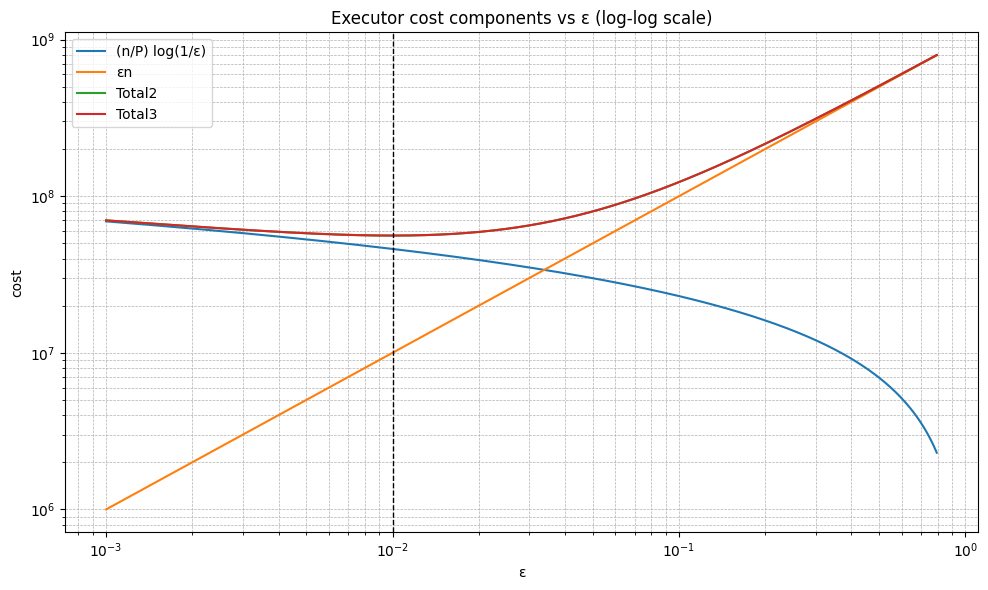

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Fix n and P (only ratios matter for the plot)
n = 1e9
P = 100.0

# Define a range of epsilon values (avoid 0 and 1)
eps_vals = np.logspace(-3, -0.1, 500)   # from 1e-3 to about 0.316

# Components, ignoring the log log term
term1 = (n / P) * np.log(1.0 / eps_vals)   # (n/P) * log(1/eps)
#term1 = (1 / P) * np.log(1.0 / eps_vals)   # (n/P) * log(1/eps)
term3 = n * eps_vals                       # eps * n
#term3 = 1 * eps_vals                       # eps * n
total2 = term1 + term3
term2 = (1/P)* np.log(np.log(eps_vals * n / P))
total3 = term1 + term2 + term3
                      

# Plot
fig, ax = plt.subplots(figsize=(10,6))
plt.loglog(eps_vals, term1, label="(n/P) log(1/ε)")
plt.loglog(eps_vals, term3, label="εn")
plt.loglog(eps_vals, total2, label="Total2")
plt.loglog(eps_vals, total3, label="Total3")


ax.axvline(x=1/P, color='black', linestyle='--', linewidth=1)

plt.xlabel("ε")
plt.ylabel("cost")
plt.title("Executor cost components vs ε (log-log scale)")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

plt.show()

-----HERE Pretty sure of math up to here.


In [ ]:
----- HERE edit below

If we do so this affects other performance metrics as follows:

$$S_{\text{exec}} = O(B+\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})
                  + \tfrac{n}{P} + \varepsilon n) = O(B+ P \log(\tfrac{n}{P^2})
                  + \tfrac{n}{P})$$

$$T_{\text{driver}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon n) + \varepsilon n\right)
                    = O\left(P^2\log(\tfrac{n}{P}) + \tfrac{n}{P}\right)$$

$$S_{\text{driver}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P}) + \varepsilon n\right)
                    = O\left(P^2\log(\tfrac{n}{P^2}) + \tfrac{n}{P}\right)$$


If we used the modified version of the Spark GK Sketch implementation that scales the head buffer
proportionally to the maximum bound on sketch size then the above becomes

$$S_{\text{exec, mod}} = O(\tfrac{1}{\varepsilon} \log(\varepsilon \tfrac{n}{P})
                  + \tfrac{n}{P} + \varepsilon n)
                  = O(P \log(\tfrac{n}{P^2}) + \tfrac{n}{P})$$

$$T_{\text{driver, mod}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P}) + \varepsilon n\right)
                    = O\left(P^2\log(\tfrac{n}{P^2}) + \tfrac{n}{P}\right)$$

$$S_{\text{driver, mod}} = O\left(\tfrac{P}{\varepsilon}\log(\varepsilon \tfrac{n}{P}) + \varepsilon n\right)
                    = O\left(P^2\log(\tfrac{n}{P^2}) + \tfrac{n}{P}\right)$$

### A New Primitive: TreeReduceX

Either approach places quite significant memory and computational load on the driver.
Since the driver is often less endowed than a cluster node running an executor,
this could cause the driver to become a computational bottleneck or
to run out of memory.

As stated, both the driver time and sketch complexities have two terms.   If
$n \gg P^3$ then the second term, i.e., $\tfrac{n}{P}$, in both memory and time
complexity dominates.  We could eliminate and the memory and computation
load of the second term by offloading the merge of the final candidate
lists onto an executor and having the last executor report back just the
$k$-th order statistic.

We could also introduced a further modified version of Spark's GK sketch
implementation that replaces the GK Sketch's `collect` of $P$ sketches
into the driver with a `treeReduce` fo the sketches causing the
executors to merge sketches except for the last two sketches.
If we offload the final two sketch merges into the executors then
the driver merely has to manage counts and computing $\Delta k$.
The entire costs reduce to

$$T_{\text{exec}} = O \left(\tfrac{n}{P}\log P + P \log \tfrac{n}{P}\right)$$

$$S_{\text{exec}} = O(B+ P \log(\tfrac{n}{P^2}) + \tfrac{n}{P})$$

$$T_{\text{driver}} = O(P)$$

$$S_{\text{driver}} = O(P)$$

For $n \gg P^2$ we can further simplify $T_{exec}$ to

$$T_{\text{exec}} = O \left(\tfrac{n}{P}\log P\right)$$

Performing the analogous analysis for the modification to GK Sketch
in which we scale $B$ proportional to the maximum size of the
sketch, we get

$$T_{\text{exec, mod}} = O \left(\tfrac{n}{P}\log P\right)$$

$$S_{\text{exec, mod}} = O(P \log(\tfrac{n}{P^2}) + \tfrac{n}{P})$$

$$T_{\text{driver, mod}} = O(P)$$

$$S_{\text{driver, mod}} = O(P)$$


The space complexity on the driver node is even worse.

Part                             | Size                                                                  |
---------------------------------|-----------------------------------------------------------------------|
GK summaries pre-merge           | $O\left(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})\right)$ |
GK summary post-merge            | $O\left(\frac{1}{\varepsilon}\,\log(\varepsilon n)\right)$            |
Candidate list from `treeReduce` | $\Theta(\varepsilon n)$                                               |

For practical values of $P$, the pre-merge size would dominate over the post-merge, but
if necessary to save memory, the driver can deallocate all sketches before receiving
the `treeReduce` thus the space complexity
becomes

$$S_{driver} = \max\left(O(\tfrac{P}{\varepsilon} \log(\varepsilon \tfrac{n}{P})), \Theta(\varepsilon n)\right)$$


with $\varepsilon = P/n$ we get

$$S_{driver} = \Theta\left(\frac{1}{\varepsilon} \log(\varepsilon n)+ \varepsilon n\right)
               = \Theta\left(\frac{n}{P} \log P + P\right) $$

For the big data regime we assume $n > P^2$ and thus the above simplifies to

$$S_{driver} = \Theta\left(\frac{n}{P} \log P\right) $$

This means the space requirement in the driver grows asymptotically larger than the memory requirement of any
given executor.  Often the driver is not a well endowed node.

We therefore abandon GK-select using $\varepsilon = P/n$.


For example we could set $\varepsilon$ to be bound by a constant to minimize the cost of merging.

$$\varepsilon = \frac{P}{n} \tag{@eq:tight}$$

### Bound memory used for sketches

Ideally the digests would never be more than a small
percentage of the system memory on any cluster node.

We can thus bound the digest space relative to the number of
objects stored in each node

  $$R(n, p) = \frac{S_{GK}(n, p)}{n_i} < \alpha\tag{@eq:R1}$$

where $\alpha \ll 1$ and $n_i$ is the number of items in the $ith$
partition. For example we may set $\alpha = 0.01$.

Assuming that partitions contain an even portion of the data,
$\frac{n}{P}$, formula #eq:R1
becomes

$$R(n,P) =  \Theta\left(\frac{\frac{1}{\varepsilon}\,\log(\varepsilon n/P)+ \varepsilon n}
     {n/P}\right) < \alpha$$

$$R(n,P) =  \Theta\left(\frac{P}{n\varepsilon}\,\log(\varepsilon n/P)+ \varepsilon P \right) < \alpha$$

If we set $\varepsilon = \frac{q}{P}$ where $q < 1$, the inequality above
becomes

$$R(n,P) =  \Theta\left(\frac{P^2}{n q} \log\frac{qn}{P^2} + q\right) < \alpha \tag{@eq:R2}$$


By the definition of $\Theta$

$$f(n)\in\Theta \left(g(n)\right)
\leftrightarrow
\exists\,c_{1}>0,\;c_{2}>0, n_{0}\in\mathbb n\;
\text{such that}\;
c_{1}g(n) \le f(n) \le c_{2}g(n)
\quad\forall\,n\ge n_{0}.$$

Using the definition above, we can rewrite #eq:R2 as



$$R(n,p) \le c_2 \cdot \left(\frac{P^2}{n q} \log\frac{qn}{P^2} + q\right) < \alpha \quad\forall\,n\ge n_{0}. \tag{@eq:R3}$$

Inequality #eq:R3 is complicated.  It grows rapidly as $n$ increases when $n$ is just above $P^2/q$ before
reducing toward the asymptotic bound $q$


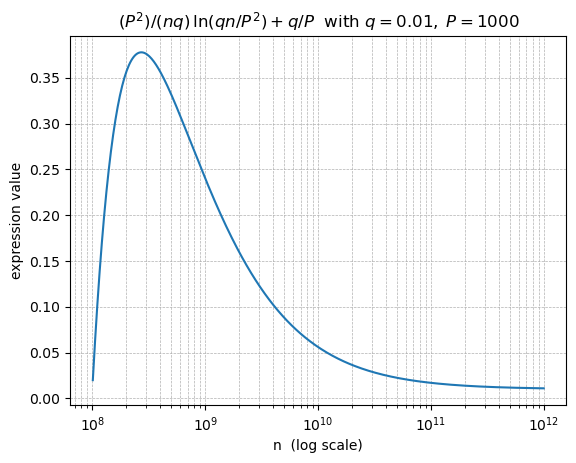

In [8]:
import numpy as np
import matplotlib.pyplot as plt

q = 0.01          # given
p = 1000          # given

# n must exceed p^2/q so that ln(q n / p^2) is defined
n_min = p**2 / q * 1.01          # 1 % above the boundary
n_max = 1e12                     # tune as you like

n = np.logspace(np.log10(n_min), np.log10(n_max), 400)
expr = (p**2) / (n * q) * np.log(q * n / p**2) + q

plt.figure()
plt.plot(n, expr)
plt.xscale('log')
plt.xlabel('n  (log scale)')
plt.ylabel('expression value')
plt.title(r'$(P^2)/(nq)\,\ln(qn/P^2) + q/P$  with $q=0.01,\;P=1000$')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

Setting $\varepsilon$ to $\frac{q}{P}$ is insufficient to hold closely to the bound on the fraction of
memory used $\alpha$.  What we have is a constrained optimizatin.  How do we minimize time complexity
while staying within this memory bound?

HERE! Given the shape of the curve below, it seems like I need to include some term that increases
the denominator of the first term for small $n$.  Something where $\epsilon$ is bigger for small
$n$ and then converges toward $\frac{q}{P}$ for large $n$.

HERE.  CONTINUE WORKING HERE!!!!!!!!!!


$$T = O\left(
      \frac{n}{P}\,[\log(1/\varepsilon)+\log\log(\varepsilon n/P)]
      + \frac{1}{\varepsilon}\,\log(\varepsilon n/P)\,\log P
      + \varepsilon n \log P\right)\tag{@eq:total3}$$


What if we try

$$\varepsilon = \frac{1}{\sqrt{n}}  \tag{@eq:balance}$$

We can balance the time complexities of the last two terms by setting them equal

$$
\frac{1}{\varepsilon}\,\log(\varepsilon n/P)\,\log P
      = \varepsilon n \log P$$

\begin{align}
  \frac{1}{\varepsilon}\,\log(\varepsilon n/P)\,\log P
      &= \varepsilon n \log P \\
  \frac{1}{\varepsilon}\,\log(\varepsilon n/P)
      &= \varepsilon n \\
\end{align}


$$
\boxed{\;
\displaystyle
\varepsilon(n,p)=
\sqrt{\frac{-\,W\!\bigl(-\,2P^{2}/n\bigr)}{2\,n}}\;.
\;}
\tag{@eq:W}
$$

\begin{align}
  \frac{1}{\varepsilon}\log P &= \varepsilon n \log P \\
  \frac{1}{\varepsilon} &= \varepsilon n \\
  \varepsilon &= \frac{1}{\sqrt{n}}  \tag{@eq:balance2}
\end{align}

Substituting Equation #eq:balance into Equation #eq:total yields

$$T = O\left(\frac{n}{P}\log\left(\frac{n}{P}\right) + \sqrt{n} \log P \right)  \tag{@eq:total2}$$

## Fastest known distributed select algorithm.

Below we show the tradeoffs between several different algorithms that can be used to find an exact
or approximate quantile.


HERE. Double check math

<center> Table @table:time : Time Complexity </center>

| Algorithm        |  Executor Time Complexity$^\dagger$                                                           | Driver Time Commplexty$^\dagger$          |
|------------------|-----------------------------------------------------------------------------------------------|-------------------------------------------|
| Sample Sort      | $O\left(\frac{n}{P} \log \frac{n}{P} + n\right)$                                              |                                           |
| Spark Sort       | $O\left(\tfrac{n}{P} \log \tfrac{n}{P}\right)$                                                |                                           |
| Al-Furaih Select | $O\left(\tfrac{n}{P} + L\log n + g\log P \log n\right)$                                       |                                           |
| Jeffers Select   | $O\left(\frac{n}{P} + (L + g P) \log n \right)$                                               |                                           |
| Count Select     |                                                                                               |                                           |
| GK Sketch        | $O\left( \frac{n}{P} \log \frac{1}{\varepsilon} + \frac{1}{\varepsilon} \log (\varepsilon n/P) \cdot \log P \right)$ |                    |
| GK Select        | $O\left(\frac{n}{P} \log P + P \log P \right)$                                                |                                           |

$^\dagger$ All of the mentioned algorithms are probabilistic in nature and thus the time and space complexities represent a worst-case
bound on expected performance.

<center> Table @table:space : Space Complexity</center>

| Algorithm        | Executor Space Complexity$^\dagger$      |   Driver Space Complexity   |
|------------------|------------------------------------------|-----------------------------|
| Sample Sort      | $O(\frac{n}{P})$                         |                             |
| Spark Sort       | $O(\frac{n}{P})$                         |                             |
| Al-Furaih Select | $O(\frac{n}{P})$                         |                             |
| Jeffers Select   | $O(\frac{n}{P})$                         |                             |
| Count Selext     |                                          |                             |
| GK Sketch        |                                          |                             |
| GK Select        |                                          |                             |

| Algorithm        | Accuracy    | Communication Model        |  Communication Cost                  | Fault Tolerance | Streaming |
|------------------|-------------|----------------------------|--------------------------------------|-----------------|-----------|
| Sample sort      | Exact       | Synchronous all-to-all MPI | Moderate - redistributes $\Theta(n)$ | Low             | No        |
| Spark sort       | Exact       | Async shuffle with retries | High - shuffles $\Theta(n)$          | High            | No        |
| Jeffers select   | Exact       | collect, broadcast         | Low                                  | High            | No        |
| Al-Furaih select | Exact       | tree reduce, broadcast     | Low                                  | High            | No        |
| GK select        | Exact       | tree reduce, broadcast     | Low                                  | High            | No        |
| GK sketch        | Approximate | tree reduce                | Low - GK summaries                   | High            | Yes       |

| Space Complexity    | expected $O(\frac{n}{P})$ | expected $O(\frac{n}{P})$ | expected $O(\frac{n}{P} \log {)$ | expected $O(\frac{n}{P})$ | $O\left(\frac{1}{\varepsilon} \log(\varepsilon n)\right)$ |

| Accuracy            |  Exact              |  Exact         | Exact          | Exact           | $\varepsilon n$  (deterministic) |

| Communication Model | Async shuffle with retries | Synchronous all-to-all MPI | tree reduce, broadcast | tree reduce, broadcast | tree reduce   |

| Communication Cost  | High - shuffles $\Theta(n)$ | Moderate - redistributes $\Theta(n)$ | Low            | Low             | Low - GK summaries   |

| Fault Tolerance     | High                | Low            | High           | High            | High           |

| Parallelism         | Moderate            | High           | High           | High            | High            |

| Streaming           | No                  | No             | No             | No              | Yes                  |

## Which algorithm is fastest?

t-ranomized select offers the best asymptotic expected performance, but for
practical values of p, sample sort, GK select, or even the GK sketch may
be faster. However, due to its high communication cost, sample sort is
unlikely to outperform GK select or T-randomized select in most scenarios.

The GK sketch may run faster than either GK select or T-randomized select,
especially when $\varepsilon$ is not too small. However, it provides
approximate results rather than exact quantiles.

A key difference between GK select and T-randomized select lies in their
communication patterns. Tree randomized Select performs $\log n$ rounds of
coordination to iteratively refine its pivot range, while GK select
completes in a single round, using an upfront estimate derived from a
GK sketch. This single-round behavior makes GK select attractive in
environments where communication cost is a dominant bottleneck. However,
this comes at the cost of an initial GK sketch pass. The
tradeoff between communication rounds and pivot accuracy is ultimately
empirical, and the best choice may depend on both system constraints
and input data characteristics.



## When Proposed Select is Faster than GK Sketch

If we set the tunable parameter to the proposed select algorithm
$\varepsilon = \frac{1}{\sqrt{n}}$ and set the GK Sketch
$\varepsilon < 1 / \sqrt{n}$.  For example,
if you try to use GK sketch to obtain an estimate that is bounded by a
constant number of
rank positions then $\epsilon \propto 1/n$ then the proposed select
algorithm is asymptotically more efficient since $1/n < 1 / \sqrt{n}$,
the proposed select would be asymptotically faster.

If however, we set the tunable parameter $\varepsilon = p/n$ then
set the GK Sketch accuracy $\varepsilon = p/n$ the sketch becomes
$O(\frac{n}{P} \log P)$ which appears to be slightly asymptotically
faster than the proposed.  I need to better understand the derivation
of the GK Sketch time complexity to ensure that this makes sense.

## Time Complexity Comparison

All of the following plots can only be considered as comparisons of time complexity and not
actual time.  These analyses omit smaller terms and constant factors that may dominate
for practical $n$ and $P$.

In [12]:
import numpy as np

def full_sort(n, p):
    """
    Approximate time complexity for full distributed sort in Spark.
    
    Parameters:
    - n: Total number of elements (can be scalar or NumPy array)
    - p: Number of partitions
    
    Returns:
    - Time estimate for full sort (same shape as n)
    """
    return (n / p) * np.log2(n / p) + n

def sample_sort(n, p):
    return (n/p) * np.log2(n/p) + p * np.log2(p)
    
def gk_select(n, p):
    """
    Time complexity for the proposed exact median (or quantile) method.
    
    Parameters:
    - n: Total number of elements (scalar or array)
    - p: Number of partitions
    
    Returns:
    - Time estimate for gk select method
    """
    #return (n / p) * np.log2(n / p) + np.sqrt(n) * np.log2(p)
    return (n / p) * np.log2(p) + p * np.log2(p)

def tr_select(n, p):
    """
    Time complexity for the proposed exact median (or quantile) method.

    Parameters:
    - n: Total nunmber of elements (scalar or array)
    
    - p: Number of partitions
    
    Returns:
    - Time estimate for Tree Randomized Select method
    """
    return (n / p) * np.log2(p) + np.log(n) * np.log2(p)


def gk_sketch(n, p, eps):
    """
    Time complexity for GK sketch method, assuming deterministic bounds.
    
    Parameters:
    - n: Total number of elements (scalar or array)
    - p: Number of partitions
    - eps: Approximation parameter ε (scalar or array of same shape as n)
    
    Returns:
    - Time estimate for GK sketch
    """
    return (n / p) * np.log2(eps * n / p) + (1 / eps) * np.log2(p)
    

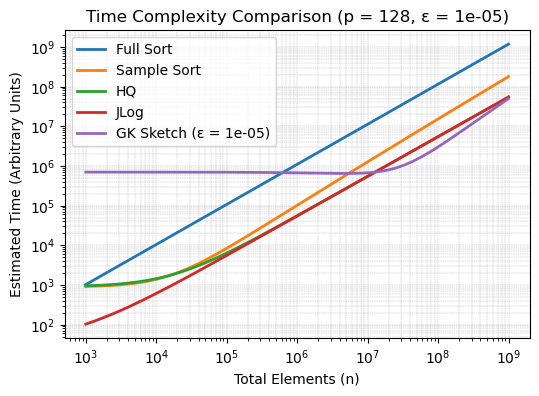

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Use a smaller n range and fixed epsilon
N_vals_small = np.logspace(3, 9, 300)
eps_fixed = 0.00001
p = 128

# Recompute with fixed epsilon
T_sort_small = full_sort(N_vals_small, p)
T_sample_small = sample_sort(N_vals_small, p)
T_gk_small = gk_select(N_vals_small, p)
T_jr_small = t_randomized_select(N_vals_small, p)
T_gk_small = gk_sketch(N_vals_small, p, eps_fixed)

plt.figure(figsize=(6, 4))
plt.plot(N_vals_small, T_sort_small, label='Full Sort', linewidth=2)
plt.plot(N_vals_small, T_sample_small, label='Sample Sort', linewidth=2)
plt.plot(N_vals_small, T_gl_small, label='GK', linewidth=2)
plt.plot(N_vals_small, T_tr_small, label='TR', linewidth=2)
plt.plot(N_vals_small, T_gk_small, label=f'GK Sketch (ε = {eps_fixed})', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Elements (n)')
plt.ylabel('Estimated Time (Arbitrary Units)')
plt.title(f'Time Complexity Comparison (P = {p}, ε = {eps_fixed})')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.3)
#plt.tight_layout()
plt.show()

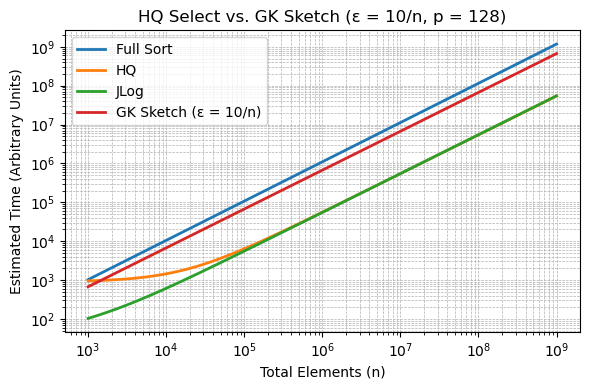

In [22]:
# Define new epsilon as k/n, where k = 10
k = 10
N_vals = np.logspace(3, 9, 300)
p = 128

eps_adaptive = k / N_vals

# Recompute curves
T_sort = full_sort(N_vals, p)
T_gk = gk_select(N_vals, p)
T_tr = tr_select(N_vals, p)
T_gk_adaptive = gk_sketch(N_vals, p, eps_adaptive)

# Plot proposed exact median vs GK sketch with adaptive ε = k/n
plt.figure(figsize=(6, 4))
plt.plot(N_vals, T_sort, label='Full Sort', linewidth=2)
plt.plot(N_vals, T_gk, label='GK', linewidth=2)
plt.plot(N_vals, T_tr, label='TR', linewidth=2)
plt.plot(N_vals, T_gk_adaptive, label='GK Sketch (ε = 10/n)', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Elements (n)')
plt.ylabel('Estimated Time (Arbitrary Units)')
plt.title(f'GK Select vs. GK Sketch (ε = 10/n, p = {p})')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

## Parallel Scaling: GK Select

We define speedup as:

$$S(n, P) = \frac{T_1(n)}{T_p(n)}\tag{@eq:sp}$$

The time complexities are expected rather than worst-case so

$$\bar{S}(n, P) = \frac{T_1(n)}{T_p(n)}\tag{@eq:esp}$$

The expected asymptotic speedup is thus defined as

$$S(P) = \lim_{n \to \infty} \bar{S}(n, P)$$

$$S(n,P) = \frac{T(n, 1)}{T(n,p)}\tag{@eq:scale}$$

$$S(n,P) = \frac{O(n)}{O\left(\frac{n}{P} \log P + P \log P \right)}\tag{@eq:scale2}$$

For $n > P^2$ Equation (@eq:scale2) becomes

$$S(n,P) \approx \frac{P}{\log P}\tag{@eq:gkscale}$$

This is near optimal speed up.

In the plot below it shows the speedup degrading when $P^2$ begins to exceed $n$.
This is a regime that seems unlikely to occur in practice with Big Data workloads.

## Parallel Scaling: Tree Randomized Select

To compute the exact median, quantile, or rank, we must examine every
item at least once, so the total work is $\Omega(n)$. With p processors,
the best-case time complexity we can hope to achieve is
$O\left(\frac{n}{P}\right)$, assuming perfect parallelization and no
overhead. This implies that the optimal speedup is linear in the number
of processors.

For the Tree Randomized Select (T-randomized) algorithm, the expected
runtime is approximately $\frac{n}{P} + \log P \log n$, so the speedup becomes:

\begin{align}
  S(p) &= \lim_{n \to \infty} \frac{n}{\frac{n}{P} + \log P \log n} \\
       &= \lim_{n \to \infty} \frac{\frac{d}{dn} n}{\frac{d}{dn}(\frac{n}{P} + \log P \log n)} \\
       &= \lim_{n \to \infty} \frac{1}{(\frac{1}{P} + \frac{\log P}{n})} = P
\end{align}

The algorithm is work-efficient and asymptotically expected
time-optimal for computing exact quantiles in a distributed setting provided
$n/\log n \gg P \log P$, up to a vanishing additive term $\log P \log n$ that
becomes negligible as $n \to \infty$.

Thus, T-randomized select achieves asymptotically optimal
expected speedup in a parallel, shared-nothing model of computation (e.g.,
Spark or MapReduce-like systems) where $P$ is typically much smaller than $n$. This
assumes data is evenly or randomly distributed across partitions, avoiding
worst-case imbalance.

Although T-randomized select algorithm is asymptotically expected
speedup optimal given computation contraints and the execution model
assumptions, the communication implied in the $\log P \log n$
may prove to be non-negligible.   Which algorithm proves better in practice for
reasonable values of $P$ will have to be determined empirically.

In [4]:
# Define new epsilon as k/n, where k = 10
n = 10**10
p = np.logspace(1, 6, 300)

# Recompute curves
T_gk = gk_select(n, p)
T_tr = tr_select(n, p)
T_sample = sample_sort(n, p)

# Plot exact median vs GK sketch with adaptive ε = k/n
plt.figure(figsize=(6, 4))
plt.plot(p, p, label='Linear Speedup $n=10^{10}$', linewidth=2)
plt.plot(p, n/T_sample, label='Sample Sort Speedup')
plt.plot(p, n/T_gk, label='GK Select Speedup')
plt.plot(p, n/T_tr, label='TR Select Speedup')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Parallelism $P$')
plt.ylabel('Speed up')
plt.title(f'GK Select Speedup')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.3)
#plt.tight_layout()
plt.show()

NameError: name 'gk_select' is not defined

## GK Select Variant

After the $T_{select}$ we could sort all the at most $k$ values nearest to the approximate quantile
which would add

$$T_{nearsort} = O(k \log k) = O(\varepsilon n \log(\varepsilon n)) \tag{@eq:nearsort}$$

$T_{nearsort} \leq T_{sketch}$ and thus does not change the average time complexity
from the proposed select algorithm, but the variant does result in $k$ sorted
values being passed up from the leaves of the `treeReduce`.  Instead of performing
an average $O(k)$ select at each level in the `treeReduce`, each node would perform
a worst-case $O(k)$ merge of already sorted values and then propagate upward in the
tree the $k$ closest to the approximate quantile.

Given that near sorting does not change the time complexity, only experiments
would reveal whether near sorting reduces the overall run time in practice.


## Bibliography

<!--
Automatically added by jupyterlab-mdx because you cited something (^lamport1994)
but hadn’t yet created a bibliography. When you run this cell it will
generate your reference list. If you’d like a different .bib file,
just change the “src:” path  below.
-->

::: bibliography
src: papers/quantile.bib
:::
